In [ ]:
linewidth=1# Drive.mount should prompt a link to mount a specific google drive
# Zane uploaded the relevant data to a new google drive,
# username = DCRThermotaxis
# password = celegans
# Log in to this account and select it to mount that drive to this colab notebook - copy its key here
# If you mount the wrong drive (e.g. your own google drive), go to runtime -> manage sessions
# Terminate this session, then rerun this cell to mount a new drive
from google.colab import drive
#drive.flush_and_unmount()
drive.mount('/content/drive')#, force_remount=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
train = pd.read_csv('/content/drive/MyDrive/3_4_3_5_DLC_3positions.csv')
train.shape

(4995, 7)

In [ ]:
train1 = pd.read_csv('/content/drive/MyDrive/3_4__3_5_Timepoints_for_Zane.csv')
train1.shape

(4995, 3)

In [ ]:
# Don't need to run - just ran once at start to unzip data in drive
#!unzip /content/drive/MyDrive/input.zip

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import seaborn as sns
import math
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib.animation as animation

from matplotlib import rc
rc('animation', html='jshtml')
sns.set_style("white")
sns.set_style("ticks") 

In [ ]:
"""
Load data in as dictionary where keys are frame number (t1,t2,etc.) and key into numpy array with the following columns:
1) Pixel index
2) Normalized (?)
3) X
4) Y
5) X_um
6) Y_um
7) RFP
8) GCaMP
9) RFP-GCaMP_Ratio
10) GCaMP_adj_x
11) GCaMP_adj_y
The remaining columns all have the same value for each row (pixel)
12) Soma_RFP_X position
13) Soma_RFP_Y position
14) Soma_RFP_Mean_Value
15) Soma_GCaMP_X position
16) Soma_GCaMP_Y position
17) Soma_GCaMP_Mean_Value
"""
import glob
numFrames = len(glob.glob("/content/drive/MyDrive/input/*.csv"))
print(numFrames)
data = {}
lacking_data = []
for i in range(numFrames):
    name = "/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t"+str(i+1)+".csv"
    temp = np.loadtxt(name, delimiter=',', skiprows=1)
    #print np.shape(temp)
    if len(np.shape(temp)) < 2:
        #print (i+1),"This frame is lacking data"
        lacking_data.append(i+1)
        continue
    else:
        data[str(i+1)] = temp
        
print(lacking_data)

# meta_dict = {}   
# with open("input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_Pos0_metadata.txt", "r") as metadata:
#     for line in metadata:
#         pieces = line.split(":") #returning a list of the key and the value
#         if len(pieces) < 2:
#             continue
#         else:
#             if "FrameKey" in pieces[0]:   #new frame dictionary
#                 key = str(int(pieces[0].split("-")[1])+1) 
#                 meta_dict[key] = {}
#             else:    
#                 if eval(pieces[0].strip()) == "MeasuredStageX":   #
#                     meta_dict[key]["StageX"] = float(pieces[1].strip().strip(','))
#                 elif eval(pieces[0].strip()) == "MeasuredStageY":
#                     meta_dict[key]["StageY"] = float(pieces[1].strip().strip(','))
#                 elif eval(pieces[0].strip()) == "ElapsedTime-ms":
#                     meta_dict[key]["ElapsedTime"] = float(pieces[1].strip().strip(','))

4995


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt: Empty input file: "/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t2318.csv"
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt: Empty input file: "/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t3059.csv"
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt: Empty input file: "/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t4348.csv"
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt: Empty input file: "/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t4359.csv"
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt: Empty input file: "/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t4376.csv"
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt

[2318, 3059, 4348, 4359, 4376, 4382, 4383, 4386, 4392, 4723, 4729, 4730, 4731, 4732, 4734, 4735, 4739, 4776, 4777, 4780, 4795, 4798, 4799, 4801, 4802, 4803, 4804, 4805, 4807, 4808, 4810, 4812, 4824, 4825, 4829, 4830, 4831, 4832, 4833, 4834, 4835, 4836, 4837, 4839, 4841, 4842, 4844, 4845, 4846, 4847, 4848, 4849, 4850, 4851, 4852, 4853, 4854, 4855, 4856, 4857, 4858, 4859, 4860, 4865, 4866, 4867, 4869, 4872, 4873, 4874, 4875, 4898, 4901, 4907, 4908, 4920, 4943, 4947, 4950, 4966, 4970, 4971, 4972, 4973]


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt: Empty input file: "/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t4943.csv"
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt: Empty input file: "/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t4947.csv"
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt: Empty input file: "/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t4950.csv"
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt: Empty input file: "/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t4966.csv"
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt: Empty input file: "/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t4970.csv"
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: UserWarning: loadtxt

In [ ]:
import json
with open("/content/drive/MyDrive/input/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_Pos0_metadata.txt", "r") as metadata_file:    
    metadata = json.load(metadata_file)
meta_dict = {}
for name, d in metadata.items():
    if "FrameKey" in name:
        frame_dict = {}
        meta_dict[int(name.split("-")[1])+1] = frame_dict
        frame_dict["StageX"] = d["MeasuredStageX"]
        frame_dict["StageY"] = d["MeasuredStageY"]
        frame_dict["ElapsedTime"] = float(d["ElapsedTime-ms"])
        

In [ ]:
xFOV = []
yFOV = []
frame_list4 = []
for frame in meta_dict.keys():
    xFOV.append(meta_dict[frame]["StageX"])
    yFOV.append(meta_dict[frame]["StageY"])
    frame_list4.append(int(frame))
frame_list_sorted4, xFOV_sorted = (list(t) for t in zip(*sorted(zip(frame_list4, xFOV))))
frame_list_sorted4, yFOV_sorted = (list(t) for t in zip(*sorted(zip(frame_list4, yFOV))))

In [ ]:
NeuronXPos = []
NeuronYPos = []
frame_list5 = []
for frame in data.keys():
    NeuronXPos.append(np.nanmean(data[frame][:,11])*1.26)
    NeuronYPos.append(np.nanmean(data[frame][:,12])*1.26)
    frame_list5.append(int(frame))
frame_list_sorted5, NeuronXPos_sorted = (list(t) for t in zip(*sorted(zip(frame_list5, NeuronXPos))))
frame_list_sorted6, NeuronYPos_sorted = (list(t) for t in zip(*sorted(zip(frame_list5, NeuronYPos))))

#print frame_list_sorted5

In [ ]:
xVal = []
deltaX = []
X0 = 15544.999 #this is position at right courner of stage where temp is Xc
for i in range(len(NeuronXPos_sorted)):
    neuron_pos = NeuronXPos_sorted[i]+xFOV_sorted[i]
    xVal.append(neuron_pos)
    deltaX.append(neuron_pos - X0)

In [ ]:
Gradient=1.0 # 19 to 21
Origin=17

In [ ]:
steepness=((Gradient)*10**-4) #converting gradient steepnes to celcius/um
deltaT=[]
TxTip = []
for i in range(len(deltaX)):
    temp_change = deltaX[i]*steepness
    deltaT.append(temp_change)
    TxTip.append(temp_change+Origin)
    
#print TxTip

<Figure size 432x288 with 0 Axes>

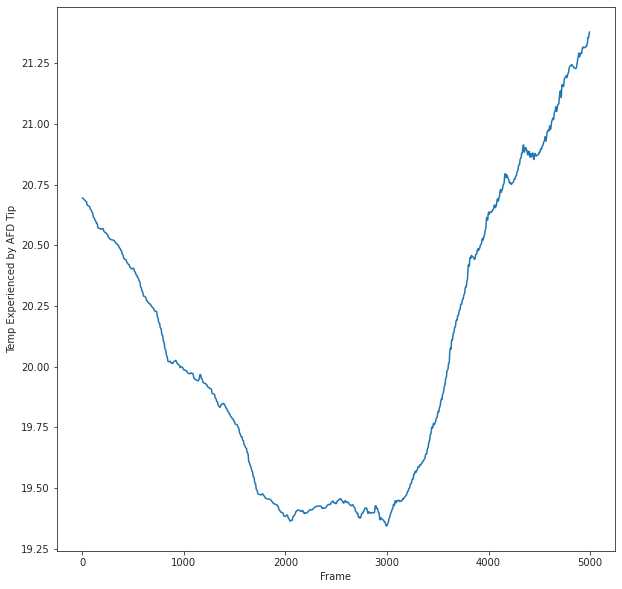

In [ ]:
from scipy.ndimage import gaussian_filter1d

smoothed_TxTip = gaussian_filter1d(TxTip, 2)
#smoothed_TxTip = np.array(eng.smoothdata(matlab.single(TxTip), 'gaussian',10))[0].tolist()
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(frame_list_sorted5,smoothed_TxTip)
plt.xlabel('Frame')
plt.ylabel('Temp Experienced by AFD Tip')
plt.show()

inserting the matlab smoothing results plot for comparison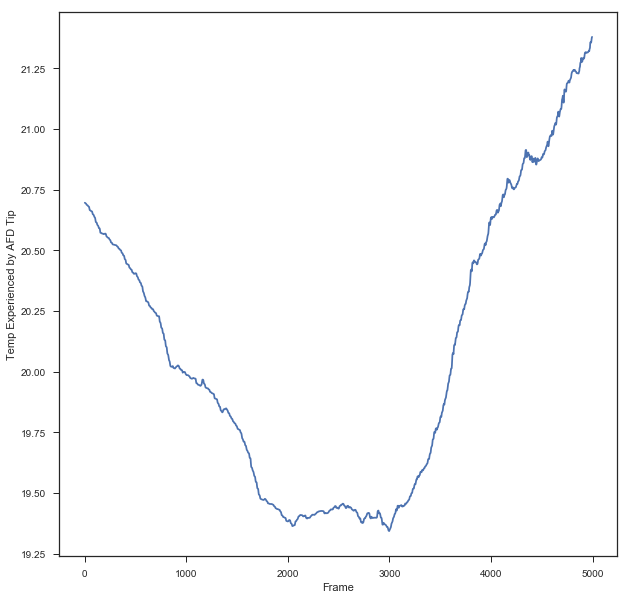

In [ ]:
yVal = []
for i in range(len(NeuronYPos_sorted)):
    neuron_pos = (NeuronYPos_sorted[i]+yFOV_sorted[i])*(-1)
    yVal.append(neuron_pos)

<Figure size 432x288 with 0 Axes>

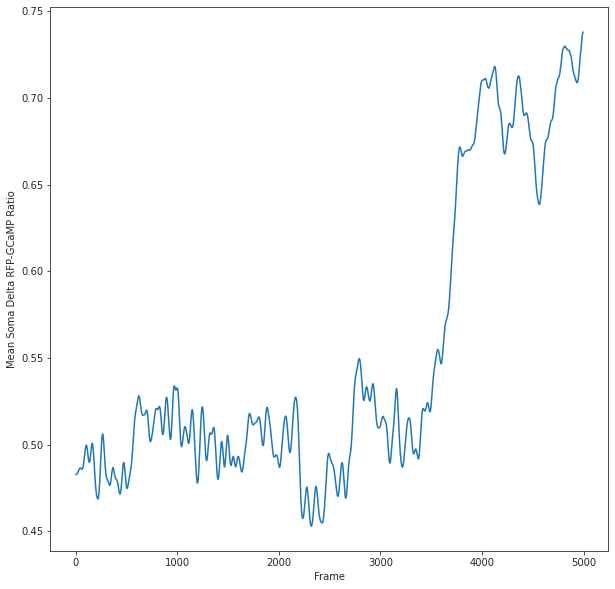

In [ ]:
Soma_RFP_mean = []
Soma_GCaMP_mean = []
SomaRatio = []
frame_list7 = []
for frame in data.keys():
    temp_RFP = np.nanmean(list(data[frame][:,13].astype(float)))
    temp_GCaMP = np.nanmean(list(data[frame][:,16].astype(float)))
    Soma_RFP_mean.append(temp_RFP)
    Soma_GCaMP_mean.append(temp_GCaMP)
    SomaRatio.append(temp_GCaMP/temp_RFP)
    frame_list7.append(int(frame))
    
frame_list_sorted7, Soma_RFP_mean_sorted, Soma_GCaMP_mean_sorted, Soma_Ratio_sorted = (list(t) for t in zip(*sorted(zip(frame_list7,\
                                                            Soma_RFP_mean, Soma_GCaMP_mean, SomaRatio))))

# Trying removing isoutlier step that was in original code to get rid of MATLAB dependency:

#where_out = eng.isoutlier(matlab.single(Soma_Ratio_sorted), 'mean')
#Soma_Ratio_sorted_outlierTrim = np.where(where_out, np.nan, Soma_Ratio_sorted)[0].tolist()
#Soma_Ratio_smoothed = np.array(eng.smoothdata(matlab.single(Soma_Ratio_sorted_outlierTrim), 'gaussian',90))[0].tolist()
Soma_Ratio_smoothed = gaussian_filter1d(Soma_Ratio_sorted, 17)

plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(frame_list_sorted7,Soma_Ratio_smoothed)
plt.xlabel('Frame')
plt.ylabel('Mean Soma Delta RFP-GCaMP Ratio')
plt.show()

Adding in old, MATLAB dependent smoothed Soma ratio to compare: 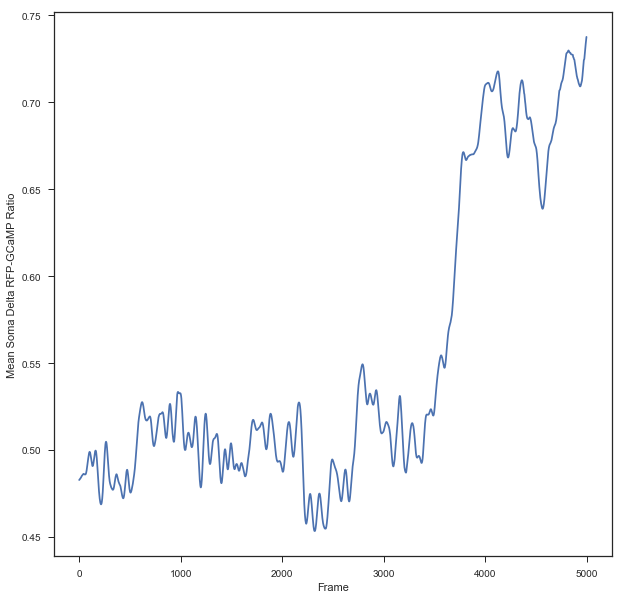

<Figure size 432x288 with 0 Axes>

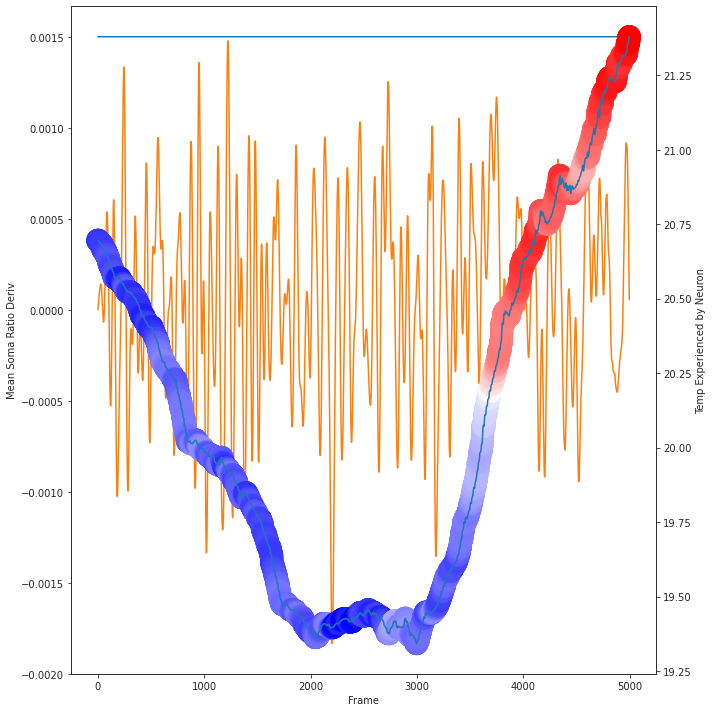

In [ ]:
Soma_Ratio_deriv = [0]
Soma_Ratio_deriv.extend(np.diff(Soma_Ratio_smoothed))

#set test threshold
thresh_val = 0.0015
threshold = []
check = 0
transitions = []
transition_ind = []
for i in range(len(frame_list_sorted7)):
    threshold.append(thresh_val)
    if Soma_Ratio_deriv[i]>=thresh_val and check == 0:
        transitions.append(frame_list_sorted7[i])
        transition_ind.append(i)
        check = 1
    elif Soma_Ratio_deriv[i]<thresh_val and check == 1:
        check = 0
    else:
        continue

plt.clf()
fig, ax1 = plt.subplots(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
ax1.plot(frame_list_sorted7,threshold)
for i in transitions:
    ax1.axvline(x=i, color='r', linewidth=4)
ax1.plot(frame_list_sorted7,Soma_Ratio_deriv)
ax1.set_xlabel('Frame')
ax1.set_ylabel('Mean Soma Ratio Deriv')

ax2 = ax1.twinx()
ax2.plot(frame_list_sorted5,smoothed_TxTip)
ax2.scatter(frame_list_sorted5,smoothed_TxTip, c=Soma_Ratio_smoothed, cmap='bwr', s=500)
ax2.set_ylabel('Temp Experienced by Neuron')

fig.tight_layout()
plt.show()

In [ ]:
Time_zane = []
frame_list9 = []
for frame in meta_dict.keys():
    Time_zane.append(float(meta_dict[frame]["ElapsedTime"]))
    frame_list9.append(int(frame))
frame_list_sorted9, Time_sorted_zane = (list(t) for t in zip(*sorted(zip(frame_list9, Time_zane))))

Time_df = pd.DataFrame()
Time_df['frame'] = frame_list_sorted9
Time_df['msec'] = Time_sorted_zane
Time_df.to_csv('3_4__3_5_Timepoints_for_Zane.csv')

In [ ]:
Time = []
frame_list8 = []
for frame in meta_dict.keys():
    if int(frame) in lacking_data:
        continue
    else:
        Time.append(float(meta_dict[frame]["ElapsedTime"]))
        frame_list8.append(int(frame))
frame_list_sorted8, Time_sorted = (list(t) for t in zip(*sorted(zip(frame_list8, Time))))

if frame_list_sorted8 == frame_list_sorted7:
    print('yay')
else:
    print(len(frame_list_sorted7), len(frame_list_sorted8))
    
dRat_dt = [0]
diffT = [0]
diffT.extend(np.diff(Time_sorted))

for i in range(1, len(diffT)):
    dRat_dt.append(float(Soma_Ratio_deriv[i])/float(diffT[i]))

yay


<Figure size 432x288 with 0 Axes>

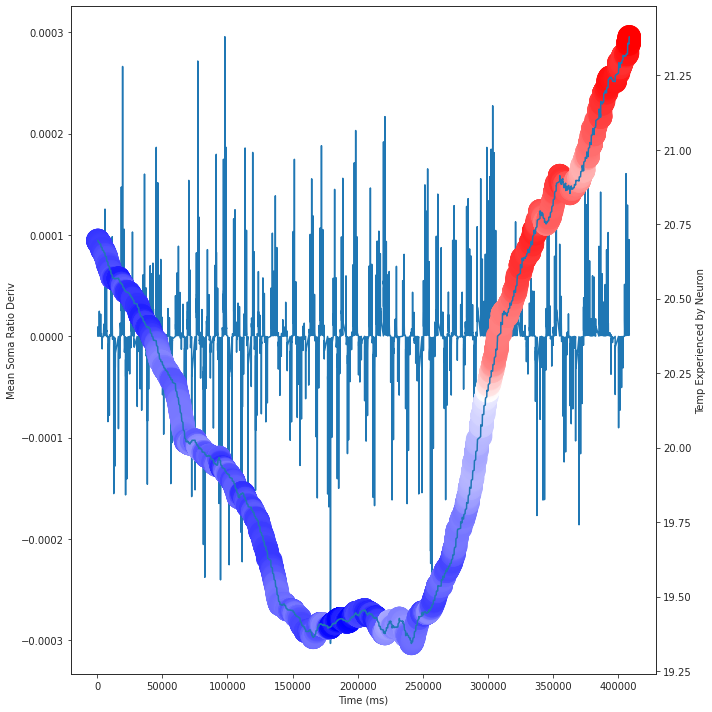

In [ ]:
plt.clf()
fig, ax1 = plt.subplots(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
#ax1.plot(Time_sorted,threshold)
for i in transitions:
    ax1.axvline(x=i, color='r', linewidth=4)
ax1.plot(Time_sorted,dRat_dt)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Mean Soma Ratio Deriv')

ax2 = ax1.twinx()
ax2.plot(Time_sorted,smoothed_TxTip)
ax2.scatter(Time_sorted,smoothed_TxTip, c=Soma_Ratio_smoothed, cmap='bwr', s=500)
ax2.set_ylabel('Temp Experienced by Neuron')

fig.tight_layout()
plt.show()

<Figure size 432x288 with 0 Axes>

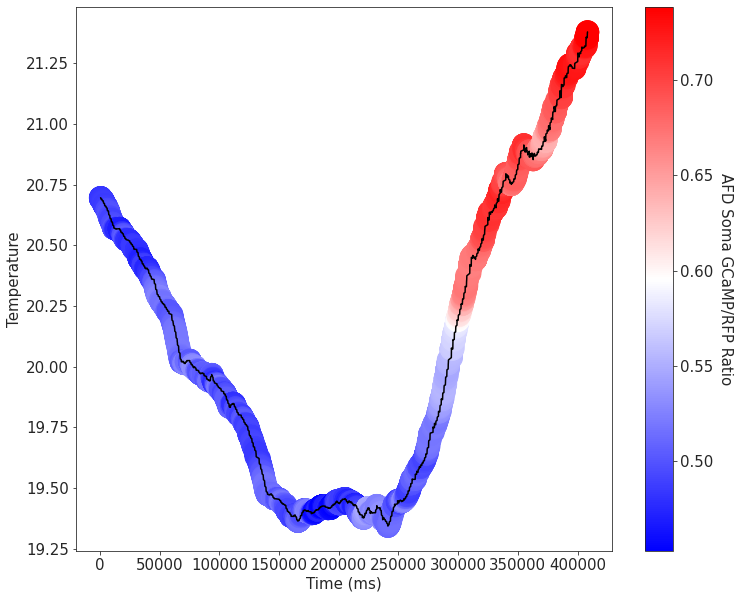

<function matplotlib.pyplot.close>

In [ ]:
plt.clf()
plt.figure(figsize=(12,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(Time_sorted,smoothed_TxTip,'k')
plt.scatter(Time_sorted,smoothed_TxTip, c=Soma_Ratio_smoothed, cmap='bwr', s=500)
plt.xlabel('Time (ms)', fontsize=15)
plt.ylabel('Temperature', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=15)
cbar.set_label('AFD Soma GCaMP/RFP Ratio', rotation=270,fontsize=15,labelpad=20)
plt.show()
plt.close

<Figure size 432x288 with 0 Axes>

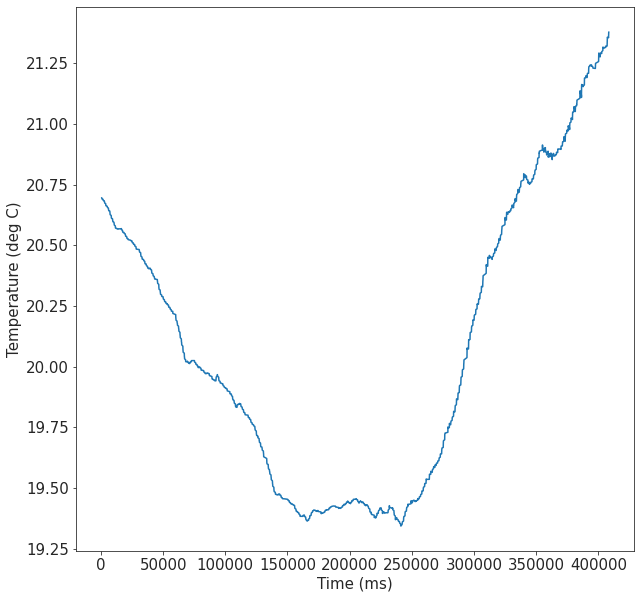

<Figure size 432x288 with 0 Axes>

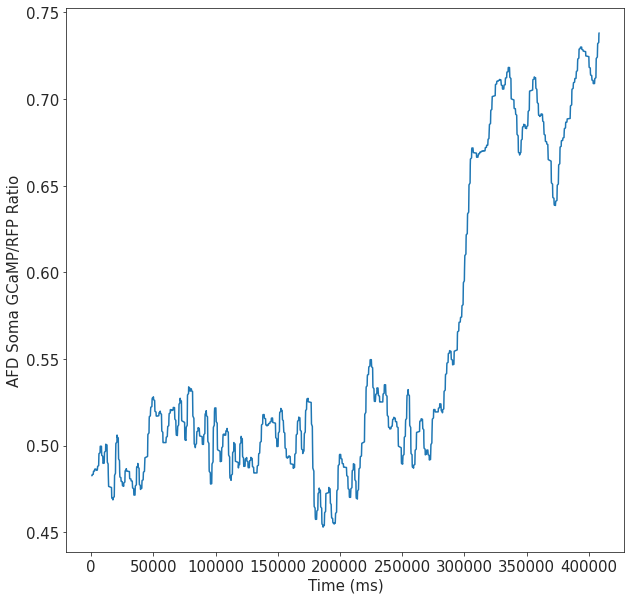

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(Time_sorted,smoothed_TxTip)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
plt.xlabel('Time (ms)', fontsize=15)
plt.ylabel('Temperature (deg C)', fontsize=15)
plt.show()

plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(Time_sorted,Soma_Ratio_smoothed)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
plt.xlabel('Time (ms)', fontsize=15)
plt.ylabel('AFD Soma GCaMP/RFP Ratio', fontsize=15)
plt.show()

In [ ]:
Temp_deriv = [0]
Temp_deriv.extend(np.diff(smoothed_TxTip))
dTemp_dt = [0]

for i in range(1, len(diffT)):
    dTemp_dt.append(float(Temp_deriv[i])/float(diffT[i]))

In [ ]:
DLC_data = pd.read_csv('/content/drive/MyDrive/3_4_3_5_DLC_3positions.csv')

In [ ]:
Soma_Ratio_smoothed = gaussian_filter1d(Soma_Ratio_sorted, 17)

Head_x = gaussian_filter1d(DLC_data['head_x'].values.tolist(), 17)
print(Head_x)
Head_y = gaussian_filter1d(DLC_data['head_y'].values.tolist(), 17)
AFD_x = gaussian_filter1d(DLC_data['AFD_x'].values.tolist(), 17)
AFD_y = gaussian_filter1d(DLC_data['AFD_y'].values.tolist(), 17)
Neck_x = gaussian_filter1d(DLC_data['neck_x'].values.tolist(), 17)
Neck_y = gaussian_filter1d(DLC_data['neck_y'].values.tolist(), 17)
DLC_time = DLC_data['time'].values.tolist()


[274.90280421 274.8773747  274.8265247  ... 595.87161027 595.89911551
 595.91295314]


<Figure size 432x288 with 0 Axes>

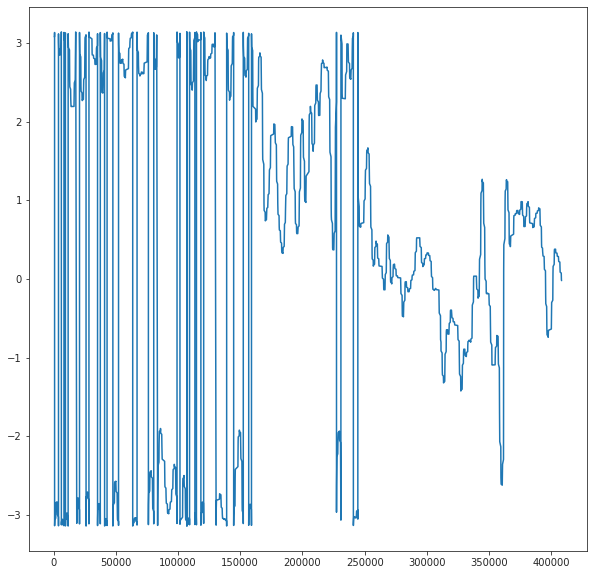

In [ ]:
AFD_Neck_line_x = []
AFD_Neck_line_y = []
for i in range(len(Head_x)):
    AFD_Neck_line_x.append(AFD_x[i]-Neck_x[i])
    AFD_Neck_line_y.append(-(AFD_y[i]-Neck_y[i]))
AFD_Neck_heading = np.arctan2(AFD_Neck_line_y,AFD_Neck_line_x)

plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, AFD_Neck_heading)
#plt.xlabel('Time (ms)')
#plt.ylabel('Soma Ratio')
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

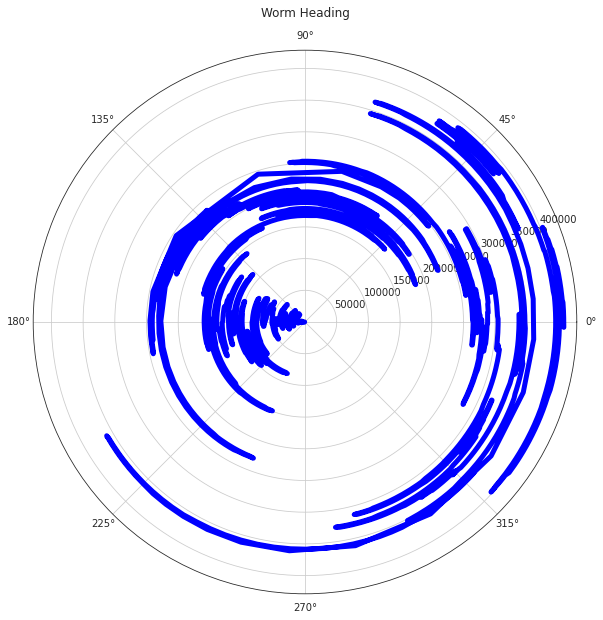

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.polar(AFD_Neck_heading, DLC_time, lw=5, color='b')
#plt.xlabel('Time (ms)')
#plt.ylabel('Soma Ratio')
plt.title('Worm Heading')
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

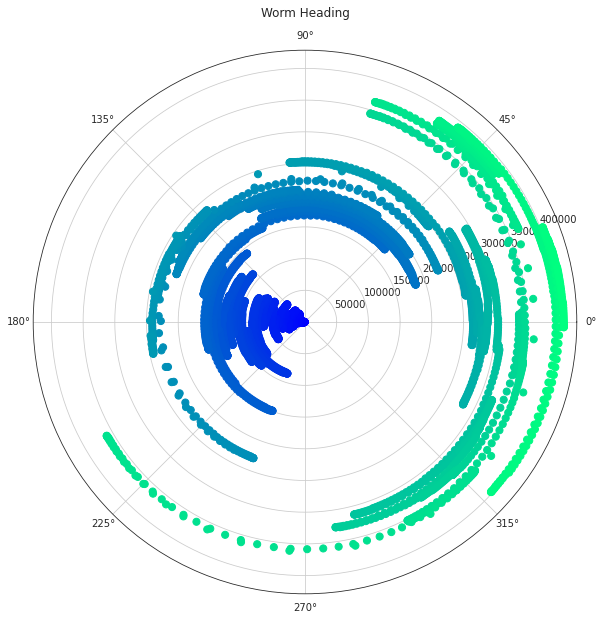

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
ax = plt.subplot(1, 1, 1, polar=True)
ax.scatter(AFD_Neck_heading, DLC_time, c=DLC_time, s=50, cmap='winter')
#plt.xlabel('Time (ms)')
#plt.ylabel('Soma Ratio')
plt.title('Worm Heading')
plt.show()
plt.close()


In [ ]:
Head_x_deriv = [0]
Head_x_deriv.extend(np.diff(Head_x))
Head_y_deriv = [0]
Head_y_deriv.extend(np.diff(Head_y))
AFD_x_deriv = [0]
AFD_x_deriv.extend(np.diff(AFD_x))
AFD_y_deriv = [0]
AFD_y_deriv.extend(np.diff(AFD_y))
Neck_x_deriv = [0]
Neck_x_deriv.extend(np.diff(Neck_x))
Neck_y_deriv = [0]
Neck_y_deriv.extend(np.diff(Neck_y))

In [ ]:
DLC_Time_deriv = [0]
DLC_Time_deriv.extend(np.diff(DLC_time))

In [ ]:
Head_vel = [0]
for i in range(1,len(Head_x_deriv)):
    Head_vel.append(np.sqrt((Head_x_deriv[i]**2)+(Head_y_deriv[i]**2))/DLC_Time_deriv[i])

<Figure size 432x288 with 0 Axes>

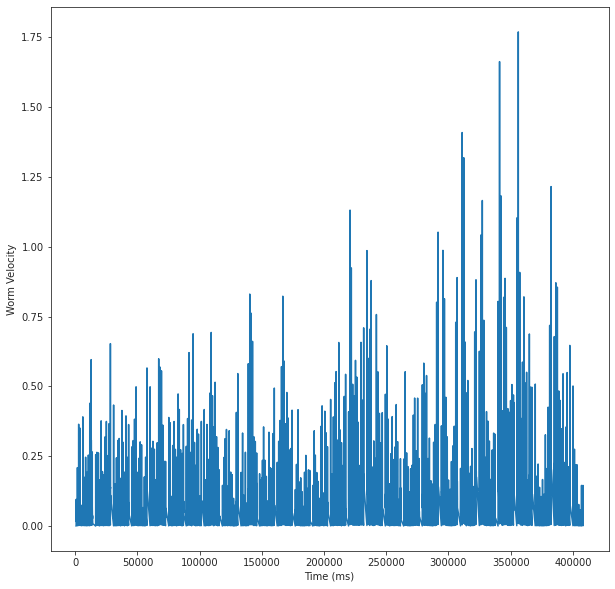

In [ ]:
AFD_vel = [0]
for i in range(1,len(AFD_x_deriv)):
    AFD_vel.append(np.sqrt((AFD_x_deriv[i]**2)+(AFD_y_deriv[i]**2))/DLC_Time_deriv[i])
Neck_vel = [0]
for i in range(1,len(Neck_x_deriv)):
    Neck_vel.append(np.sqrt((Neck_x_deriv[i]**2)+(Neck_y_deriv[i]**2))/DLC_Time_deriv[i])
Avg_velo = []
for i in range(len(Head_vel)):
    Avg_velo.append(np.mean([Head_vel[i], AFD_vel[i], Neck_vel[i]]))
    
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, Avg_velo)
plt.xlabel('Time (ms)')
plt.ylabel('Worm Velocity')
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

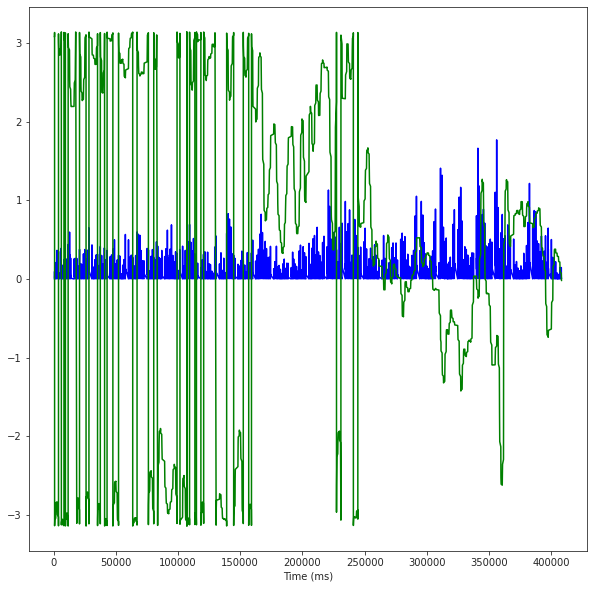

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, Avg_velo, 'b')
plt.plot(DLC_time, AFD_Neck_heading, 'g')
plt.xlabel('Time (ms)')
#plt.ylabel('Worm Velocity')
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

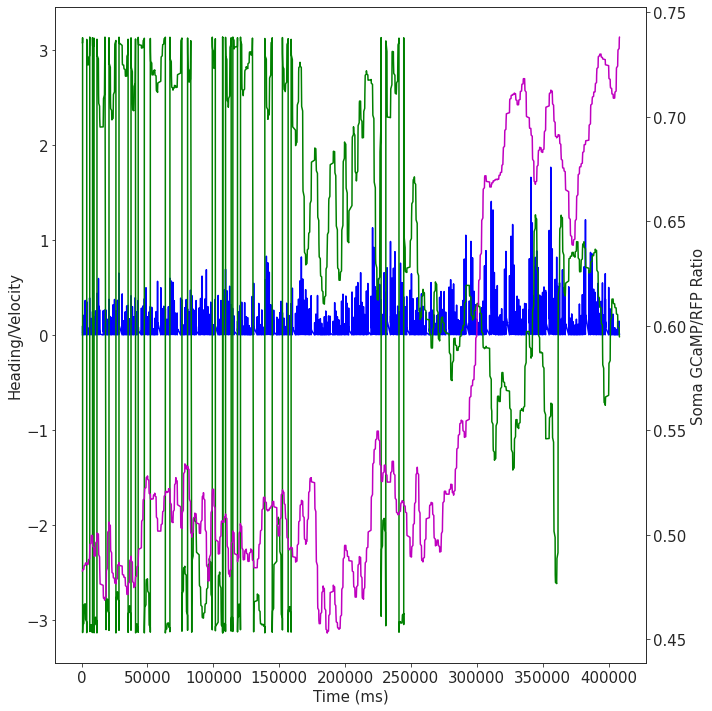

In [ ]:
plt.clf()
fig, ax1 = plt.subplots(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)

ax1.plot(DLC_time, Avg_velo, 'b')
ax1.plot(DLC_time, AFD_Neck_heading, 'g')
ax1.set_ylabel('Heading/Velocity', fontsize = 15)
ax1.set_xlabel('Time (ms)', fontsize = 15)
#ax1.set_ylim(19.25,21.75)
#ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
ax2.plot(Time_sorted,Soma_Ratio_smoothed, 'm')
ax2.set_ylabel('Soma GCaMP/RFP Ratio', fontsize = 15)
#ax2.set_ylim(0,1.1)
#ax2.legend(labels=['AFD', 'AIY'], fontsize = 15, loc='upper right')

plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

fig.tight_layout()
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

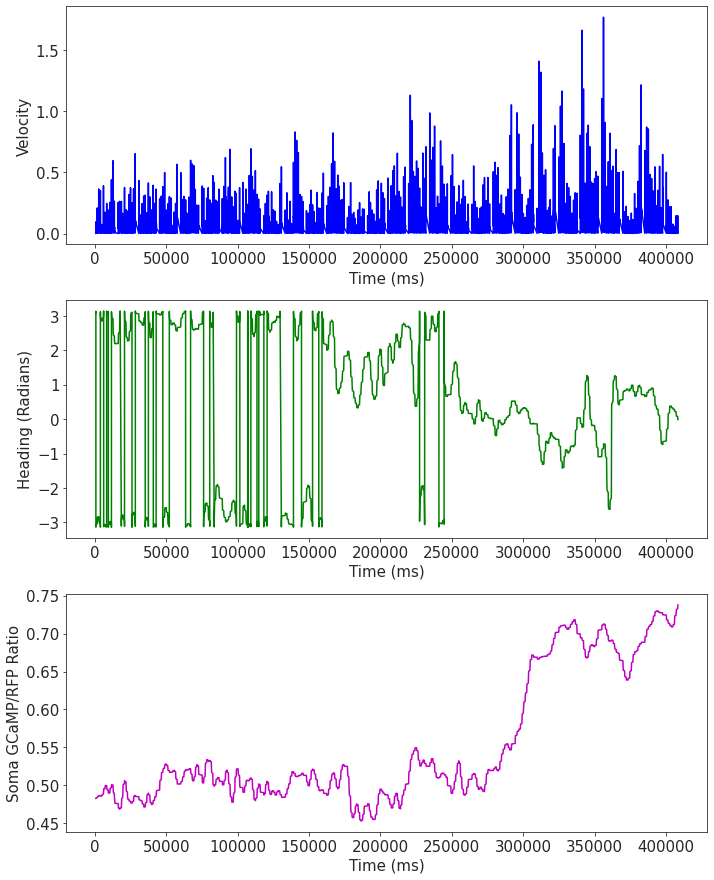

In [ ]:
plt.clf()
fig = plt.subplots(nrows=3,ncols=1,figsize=(10,12))#,dpi=300)#plt.ylim(0,1)

ax1 = plt.subplot(3,1,1)
ax1.plot(DLC_time, Avg_velo, 'b')
ax1.set_ylabel('Velocity', fontsize = 15)
ax1.set_xlabel('Time (ms)', fontsize = 15)
#ax1.set_ylim(19.25,21.75)
#ax1.set_xlim(0,AIY_Nat1['Time'][len(AIY_Nat1['Time'])-1])
#ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = plt.subplot(3,1,2)
ax2.plot(DLC_time, AFD_Neck_heading, 'g')
ax2.set_ylabel('Heading (Radians)', fontsize = 15)
ax2.set_xlabel('Time (ms)', fontsize = 15)
#ax2.set_ylim(0,1.1)
#ax2.set_xlim(0,AIY_Nat1['Time'][len(AIY_Nat1['Time'])-1])
#ax2.legend(labels=['AFD', 'AIY'], fontsize = 15, loc='upper center')

#ax1.set_ylim(19.25,21.75)
#ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

ax3 = plt.subplot(3,1,3)
ax3.plot(Time_sorted,Soma_Ratio_smoothed, 'm')
ax3.set_ylabel('Soma GCaMP/RFP Ratio', fontsize = 15)
ax3.set_xlabel('Time (ms)', fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

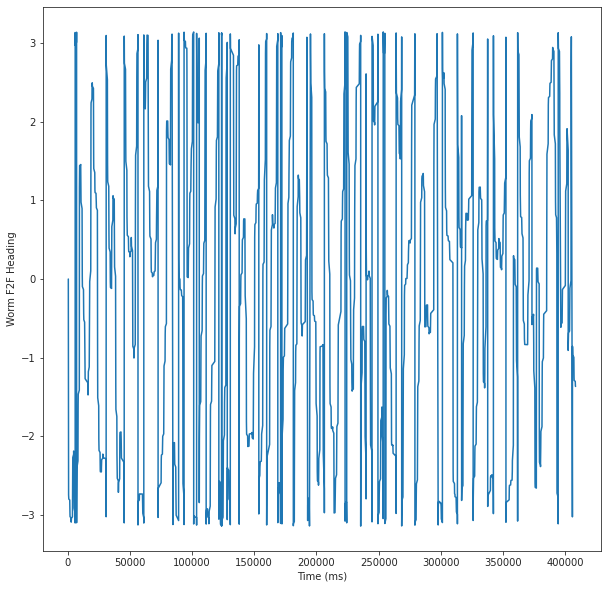

In [ ]:
Head_f2f_heading = np.arctan2(Head_y_deriv, Head_x_deriv)
AFD_f2f_heading = np.arctan2(AFD_y_deriv, AFD_x_deriv)
Neck_f2f_heading = np.arctan2(Neck_y_deriv, Neck_x_deriv)

Avg_f2f_heading = []
for i in range(len(Head_f2f_heading)):
    Avg_f2f_heading.append(np.mean([Head_f2f_heading[i], AFD_f2f_heading[i], Neck_f2f_heading[i]]))
    
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, Neck_f2f_heading)
plt.xlabel('Time (ms)')
plt.ylabel('Worm F2F Heading')
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

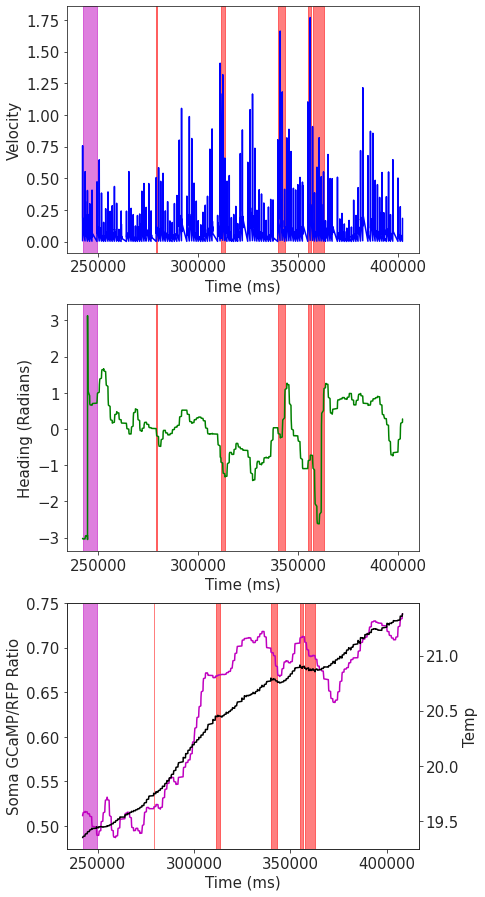

In [ ]:
#Plot subset
sub_start = 3000
sub_end = len(Soma_Ratio_smoothed)-1


plt.clf()
fig = plt.subplots(nrows=2,ncols=1,figsize=(6,12))#,dpi=300)#plt.ylim(0,1)

ax1 = plt.subplot(3,1,1)
ax1.plot(DLC_time[sub_start:sub_end], Avg_velo[sub_start:sub_end], 'b')
ax1.axvspan(242055, 249503, color='m',alpha=0.5)
ax1.axvspan(278933, 279200, color='r',alpha=0.5)
ax1.axvspan(311417, 313314, color='r',alpha=0.5)
ax1.axvspan(339885, 343274, color='r',alpha=0.5)
ax1.axvspan(354920, 356393, color='r',alpha=0.5)
ax1.axvspan(357542, 362824, color='r',alpha=0.5)
ax1.set_ylabel('Velocity', fontsize = 15)
ax1.set_xlabel('Time (ms)', fontsize = 15)
#ax1.set_ylim(19.25,21.75)
#ax1.set_xlim(0,AIY_Nat1['Time'][len(AIY_Nat1['Time'])-1])
#ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = plt.subplot(3,1,2)
ax2.plot(DLC_time[sub_start:sub_end], AFD_Neck_heading[sub_start:sub_end], 'g')
ax2.axvspan(242055, 249503, color='m',alpha=0.5)
ax2.axvspan(278933, 279200, color='r',alpha=0.5)
ax2.axvspan(311417, 313314, color='r',alpha=0.5)
ax2.axvspan(339885, 343274, color='r',alpha=0.5)
ax2.axvspan(354920, 356393, color='r',alpha=0.5)
ax2.axvspan(357542, 362824, color='r',alpha=0.5)
ax2.set_ylabel('Heading (Radians)', fontsize = 15)
ax2.set_xlabel('Time (ms)', fontsize = 15)
#ax2.set_ylim(0,1.1)
#ax2.set_xlim(0,AIY_Nat1['Time'][len(AIY_Nat1['Time'])-1])
#ax2.legend(labels=['AFD', 'AIY'], fontsize = 15, loc='upper center')

#ax1.set_ylim(19.25,21.75)
#ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

ax3 = plt.subplot(3,1,3)
ax3.plot(Time_sorted[sub_start:sub_end],Soma_Ratio_smoothed[sub_start:sub_end], 'm')
ax3.axvspan(242055, 249503, color='m',alpha=0.5)
ax3.axvspan(278933, 279200, color='r',alpha=0.5)
ax3.axvspan(311417, 313314, color='r',alpha=0.5)
ax3.axvspan(339885, 343274, color='r',alpha=0.5)
ax3.axvspan(354920, 356393, color='r',alpha=0.5)
ax3.axvspan(357542, 362824, color='r',alpha=0.5)
ax3.set_ylabel('Soma GCaMP/RFP Ratio', fontsize = 15)
ax3.set_xlabel('Time (ms)', fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax4 = ax3.twinx()
ax4.plot(Time_sorted[sub_start:sub_end],smoothed_TxTip[sub_start:sub_end], 'k')
ax4.set_ylabel('Temp', fontsize = 15)
ax4.set_xlabel('Time (ms)', fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

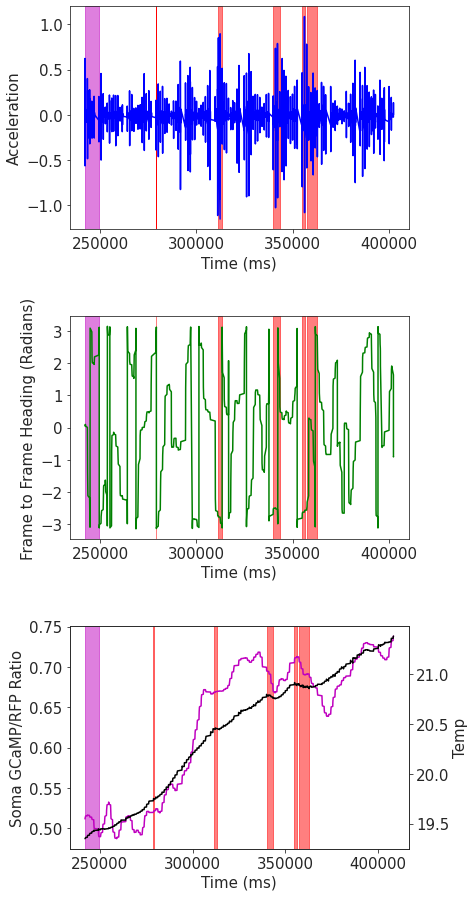

In [ ]:
acceleration = [0]
acceleration.extend(np.diff(Avg_velo))

#Plot subset
sub_start = 3000
sub_end = len(Soma_Ratio_smoothed)-1


plt.clf()
fig = plt.subplots(nrows=2,ncols=1,figsize=(6,12))#,dpi=300)#plt.ylim(0,1)

ax1 = plt.subplot(3,1,1)
ax1.plot(DLC_time[sub_start:sub_end], acceleration[sub_start:sub_end], 'b')
ax1.axvspan(242055, 249503, color='m',alpha=0.5)
ax1.axvspan(278933, 279200, color='r',alpha=1)
ax1.axvspan(311417, 313314, color='r',alpha=0.5)
ax1.axvspan(339885, 343274, color='r',alpha=0.5)
ax1.axvspan(354920, 356393, color='r',alpha=0.5)
ax1.axvspan(357542, 362824, color='r',alpha=0.5)
ax1.set_ylabel('Acceleration', fontsize = 15)
ax1.set_xlabel('Time (ms)', fontsize = 15)
#ax1.set_ylim(19.25,21.75)
#ax1.set_xlim(0,AIY_Nat1['Time'][len(AIY_Nat1['Time'])-1])
#ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = plt.subplot(3,1,2)
ax2.plot(DLC_time[sub_start:sub_end], Neck_f2f_heading[sub_start:sub_end], 'g')
ax2.axvspan(242055, 249503, color='m',alpha=0.5)
ax2.axvspan(278933, 279200, color='r',alpha=0.5)
ax2.axvspan(311417, 313314, color='r',alpha=0.5)
ax2.axvspan(339885, 343274, color='r',alpha=0.5)
ax2.axvspan(354920, 356393, color='r',alpha=0.5)
ax2.axvspan(357542, 362824, color='r',alpha=0.5)
ax2.set_ylabel('Frame to Frame Heading (Radians)', fontsize = 15)
ax2.set_xlabel('Time (ms)', fontsize = 15)
#ax2.set_ylim(0,1.1)
#ax2.set_xlim(0,AIY_Nat1['Time'][len(AIY_Nat1['Time'])-1])
#ax2.legend(labels=['AFD', 'AIY'], fontsize = 15, loc='upper center')

#ax1.set_ylim(19.25,21.75)
#ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

ax3 = plt.subplot(3,1,3)
ax3.plot(Time_sorted[sub_start:sub_end],Soma_Ratio_smoothed[sub_start:sub_end], 'm')
ax3.axvspan(242055, 249503, color='m',alpha=0.5)
ax3.axvspan(278933, 279200, color='r',alpha=0.5)
ax3.axvspan(311417, 313314, color='r',alpha=0.5)
ax3.axvspan(339885, 343274, color='r',alpha=0.5)
ax3.axvspan(354920, 356393, color='r',alpha=0.5)
ax3.axvspan(357542, 362824, color='r',alpha=0.5)
ax3.set_ylabel('Soma GCaMP/RFP Ratio', fontsize = 15)
ax3.set_xlabel('Time (ms)', fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax4 = ax3.twinx()
ax4.plot(Time_sorted[sub_start:sub_end],smoothed_TxTip[sub_start:sub_end], 'k')
ax4.set_ylabel('Temp', fontsize = 15)
ax4.set_xlabel('Time (ms)', fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

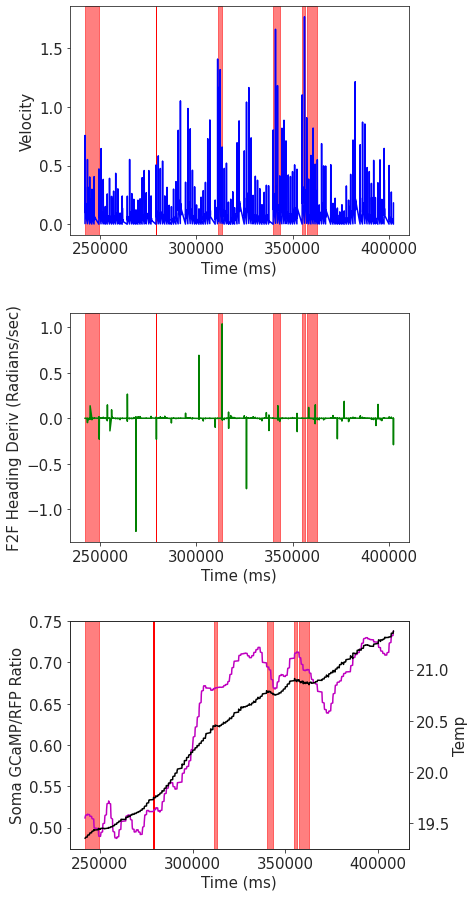

In [ ]:
Neck_f2f_heading_deriv = [0]
Neck_f2f_heading_deriv.extend(np.diff(Neck_f2f_heading))
Neck_f2f_heading_dT = [0]
for i in range(1,len(Neck_f2f_heading_deriv)):
    Neck_f2f_heading_dT.append(Neck_f2f_heading_deriv[i]/DLC_Time_deriv[i])

#Plot subset
sub_start = 3000
sub_end = len(Soma_Ratio_smoothed)-1


plt.clf()
fig = plt.subplots(nrows=2,ncols=1,figsize=(6,12))#,dpi=300)#plt.ylim(0,1)

ax1 = plt.subplot(3,1,1)
ax1.plot(DLC_time[sub_start:sub_end], Avg_velo[sub_start:sub_end], 'b')
ax1.axvspan(242055, 249503, color='r',alpha=0.5)
ax1.axvspan(278933, 279200, color='r',alpha=1)
ax1.axvspan(311417, 313314, color='r',alpha=0.5)
ax1.axvspan(339885, 343274, color='r',alpha=0.5)
ax1.axvspan(354920, 356393, color='r',alpha=0.5)
ax1.axvspan(357542, 362824, color='r',alpha=0.5)
ax1.set_ylabel('Velocity', fontsize = 15)
ax1.set_xlabel('Time (ms)', fontsize = 15)
#ax1.set_ylim(19.25,21.75)
#ax1.set_xlim(0,AIY_Nat1['Time'][len(AIY_Nat1['Time'])-1])
#ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = plt.subplot(3,1,2)
ax2.plot(DLC_time[sub_start:sub_end], Neck_f2f_heading_dT[sub_start:sub_end], 'g')
ax2.axvspan(242055, 249503, color='r',alpha=0.5)
ax2.axvspan(278933, 279200, color='r',alpha=1)
ax2.axvspan(311417, 313314, color='r',alpha=0.5)
ax2.axvspan(339885, 343274, color='r',alpha=0.5)
ax2.axvspan(354920, 356393, color='r',alpha=0.5)
ax2.axvspan(357542, 362824, color='r',alpha=0.5)
ax2.set_ylabel('F2F Heading Deriv (Radians/sec)', fontsize = 15)
ax2.set_xlabel('Time (ms)', fontsize = 15)
#ax2.set_ylim(0,1.1)
#ax2.set_xlim(0,AIY_Nat1['Time'][len(AIY_Nat1['Time'])-1])
#ax2.legend(labels=['AFD', 'AIY'], fontsize = 15, loc='upper center')

#ax1.set_ylim(19.25,21.75)
#ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

ax3 = plt.subplot(3,1,3)
ax3.plot(Time_sorted[sub_start:sub_end],Soma_Ratio_smoothed[sub_start:sub_end], 'm')
ax3.axvspan(242055, 249503, color='r',alpha=0.5)
ax3.axvspan(278933, 279200, color='r',alpha=1)
ax3.axvspan(311417, 313314, color='r',alpha=0.5)
ax3.axvspan(339885, 343274, color='r',alpha=0.5)
ax3.axvspan(354920, 356393, color='r',alpha=0.5)
ax3.axvspan(357542, 362824, color='r',alpha=0.5)
ax3.set_ylabel('Soma GCaMP/RFP Ratio', fontsize = 15)
ax3.set_xlabel('Time (ms)', fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax4 = ax3.twinx()
ax4.plot(Time_sorted[sub_start:sub_end],smoothed_TxTip[sub_start:sub_end], 'k')
ax4.set_ylabel('Temp', fontsize = 15)
ax4.set_xlabel('Time (ms)', fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

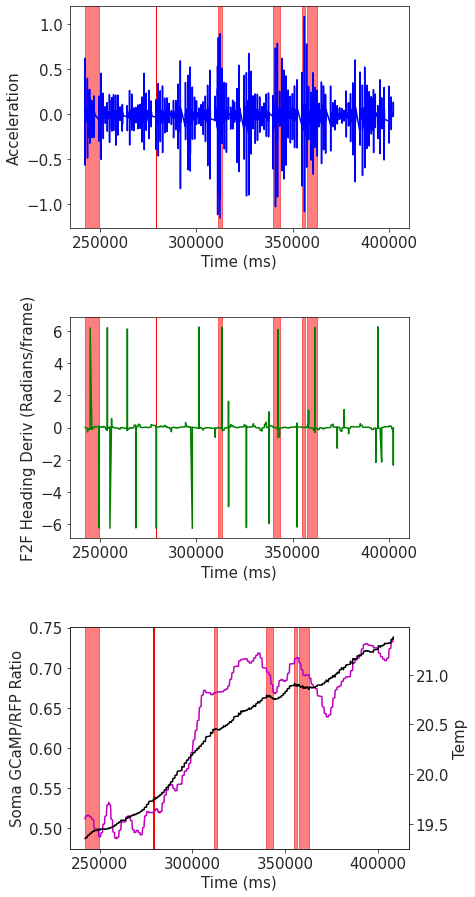

In [ ]:
acceleration = [0]
acceleration.extend(np.diff(Avg_velo))

#Plot subset
sub_start = 3000
sub_end = len(Soma_Ratio_smoothed)-1


plt.clf()
fig = plt.subplots(nrows=2,ncols=1,figsize=(6,12))#,dpi=300)#plt.ylim(0,1)

ax1 = plt.subplot(3,1,1)
ax1.plot(DLC_time[sub_start:sub_end], acceleration[sub_start:sub_end], 'b')
ax1.axvspan(242055, 249503, color='r',alpha=0.5)
ax1.axvspan(278933, 279200, color='r',alpha=1)
ax1.axvspan(311417, 313314, color='r',alpha=0.5)
ax1.axvspan(339885, 343274, color='r',alpha=0.5)
ax1.axvspan(354920, 356393, color='r',alpha=0.5)
ax1.axvspan(357542, 362824, color='r',alpha=0.5)
ax1.set_ylabel('Acceleration', fontsize = 15)
ax1.set_xlabel('Time (ms)', fontsize = 15)
#ax1.set_ylim(19.25,21.75)
#ax1.set_xlim(0,AIY_Nat1['Time'][len(AIY_Nat1['Time'])-1])
#ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = plt.subplot(3,1,2)
ax2.plot(DLC_time[sub_start:sub_end], Neck_f2f_heading_deriv[sub_start:sub_end], 'g')
ax2.axvspan(242055, 249503, color='r',alpha=0.5)
ax2.axvspan(278933, 279200, color='r',alpha=1)
ax2.axvspan(311417, 313314, color='r',alpha=0.5)
ax2.axvspan(339885, 343274, color='r',alpha=0.5)
ax2.axvspan(354920, 356393, color='r',alpha=0.5)
ax2.axvspan(357542, 362824, color='r',alpha=0.5)
ax2.set_ylabel('F2F Heading Deriv (Radians/frame)', fontsize = 15)
ax2.set_xlabel('Time (ms)', fontsize = 15)
#ax2.set_ylim(0,1.1)
#ax2.set_xlim(0,AIY_Nat1['Time'][len(AIY_Nat1['Time'])-1])
#ax2.legend(labels=['AFD', 'AIY'], fontsize = 15, loc='upper center')

#ax1.set_ylim(19.25,21.75)
#ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

ax3 = plt.subplot(3,1,3)
ax3.plot(Time_sorted[sub_start:sub_end],Soma_Ratio_smoothed[sub_start:sub_end], 'm')
ax3.axvspan(242055, 249503, color='r',alpha=0.5)
ax3.axvspan(278933, 279200, color='r',alpha=1)
ax3.axvspan(311417, 313314, color='r',alpha=0.5)
ax3.axvspan(339885, 343274, color='r',alpha=0.5)
ax3.axvspan(354920, 356393, color='r',alpha=0.5)
ax3.axvspan(357542, 362824, color='r',alpha=0.5)
ax3.set_ylabel('Soma GCaMP/RFP Ratio', fontsize = 15)
ax3.set_xlabel('Time (ms)', fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax4 = ax3.twinx()
ax4.plot(Time_sorted[sub_start:sub_end],smoothed_TxTip[sub_start:sub_end], 'k')
ax4.set_ylabel('Temp', fontsize = 15)
ax4.set_xlabel('Time (ms)', fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.show()
plt.close()

In [ ]:
reversals_head = []
reversals_velo = []
for i in range(len(Neck_f2f_heading_dT)):
    check = 0
    if abs(Neck_f2f_heading_dT[i]) > 0.1 and check == 0:
        #check = 1
        reversals_head.append(i)
        if abs(acceleration[i]) > 0.1:
            reversals_velo.append(i)
    elif abs(Neck_f2f_heading_deriv[i]) < 3 and check == 1:
        check = 0
print(reversals_head)

[78, 95, 126, 127, 387, 565, 709, 752, 911, 980, 1096, 1099, 1100, 1162, 1261, 1281, 1308, 1385, 1505, 1531, 1541, 1582, 1592, 1631, 1700, 1702, 1900, 1983, 2087, 2124, 2138, 2248, 2552, 2767, 2789, 2913, 2972, 2973, 3044, 3087, 3142, 3164, 3263, 3322, 3448, 3706, 3844, 3893, 3992, 4153, 4197, 4330, 4382, 4435, 4565, 4566, 4612, 4824, 4906, 4939]


<Figure size 432x288 with 0 Axes>

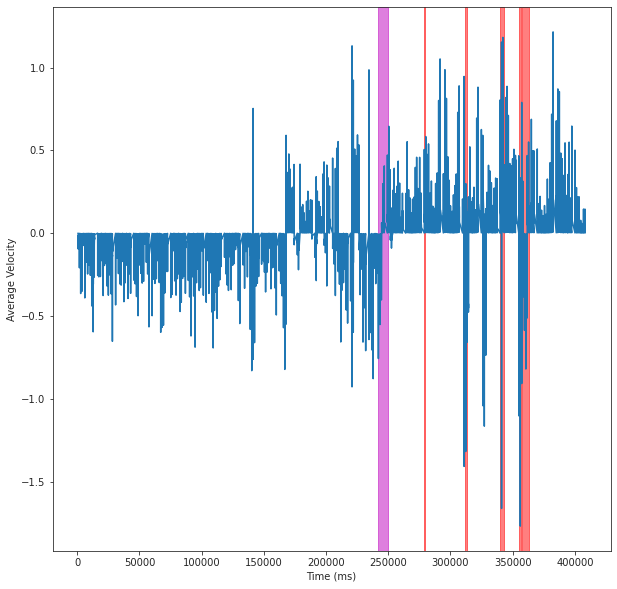

In [ ]:
def isvelocitypositive(Avg_f2f_heading, AFD_Neck_heading):
    if abs(Avg_f2f_heading - AFD_Neck_heading) < math.pi/2:
        return True
    else:
        return False
      

def signAvg_velo(Avg_velo, Avg_f2f_heading, AFD_Neck_heading):
    Avg_velo1 = []
    for i in range(len(Avg_velo)):
        if isvelocitypositive(Avg_velo[i],AFD_Neck_heading[i]):
            Avg_velo1.append(Avg_velo[i])
        else:
            Avg_velo1.append(-Avg_velo[i])
    return Avg_velo1 

Avg_velo1 = signAvg_velo(Avg_velo, Avg_f2f_heading, AFD_Neck_heading)

plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, Avg_velo1)
plt.xlabel('Time (ms)')
plt.ylabel('Average Velocity')
plt.axvspan(242055, 249503, color='m',alpha=0.5)
plt.axvspan(278933, 279200, color='r',alpha=0.5)
plt.axvspan(311417, 313314, color='r',alpha=0.5)
plt.axvspan(339885, 343274, color='r',alpha=0.5)
plt.axvspan(354920, 356393, color='r',alpha=0.5)
plt.axvspan(357542, 362824, color='r',alpha=0.5)
plt.show()
plt.close()


<Figure size 432x288 with 0 Axes>

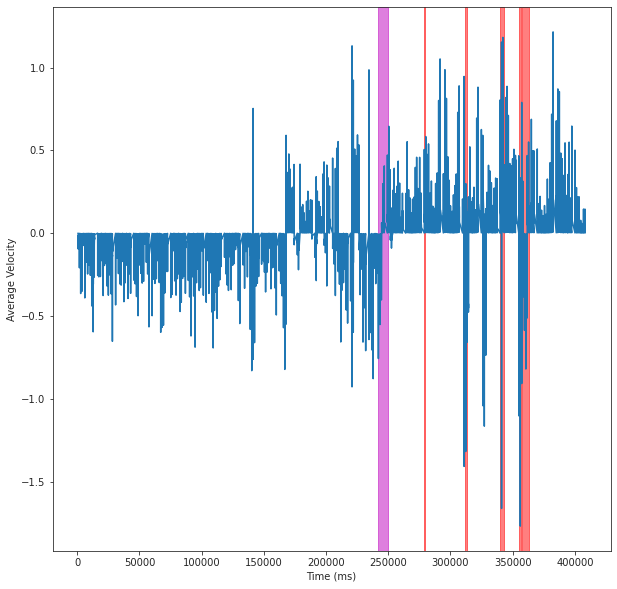

In [ ]:
Avg_velo1 = signAvg_velo(Avg_velo, Avg_f2f_heading, AFD_Neck_heading)

plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, Avg_velo1)
plt.xlabel('Time (ms)')
plt.ylabel('Average Velocity')
plt.axvspan(242055, 249503, color='m',alpha=0.5)
plt.axvspan(278933, 279200, color='r',alpha=0.5)
plt.axvspan(311417, 313314, color='r',alpha=0.5)
plt.axvspan(339885, 343274, color='r',alpha=0.5)
plt.axvspan(354920, 356393, color='r',alpha=0.5)
plt.axvspan(357542, 362824, color='r',alpha=0.5)
plt.show()
plt.close()


<Figure size 432x288 with 0 Axes>

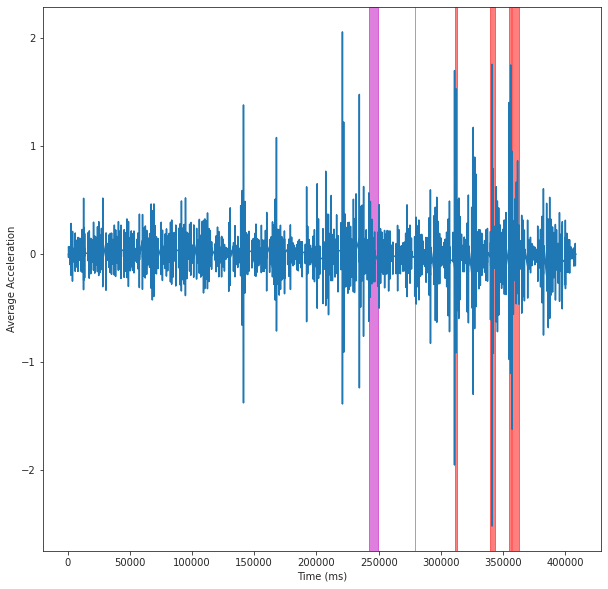

In [ ]:
acceleration1 = [0]
acceleration1.extend(list(np.diff(Avg_velo1)))

plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, acceleration1)
plt.xlabel('Time (ms)')
plt.ylabel('Average Acceleration')
plt.axvspan(242055, 249503, color='m',alpha=0.5)
plt.axvspan(278933, 279200, color='r',alpha=0.5)
plt.axvspan(311417, 313314, color='r',alpha=0.5)
plt.axvspan(339885, 343274, color='r',alpha=0.5)
plt.axvspan(354920, 356393, color='r',alpha=0.5)
plt.axvspan(357542, 362824, color='r',alpha=0.5)
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

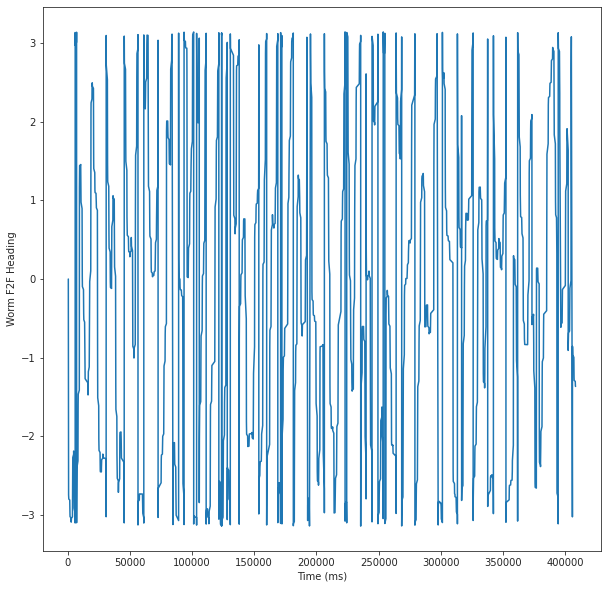

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, Neck_f2f_heading)
plt.xlabel('Time (ms)')
plt.ylabel('Worm F2F Heading')
plt.show()
plt.close()




<Figure size 432x288 with 0 Axes>

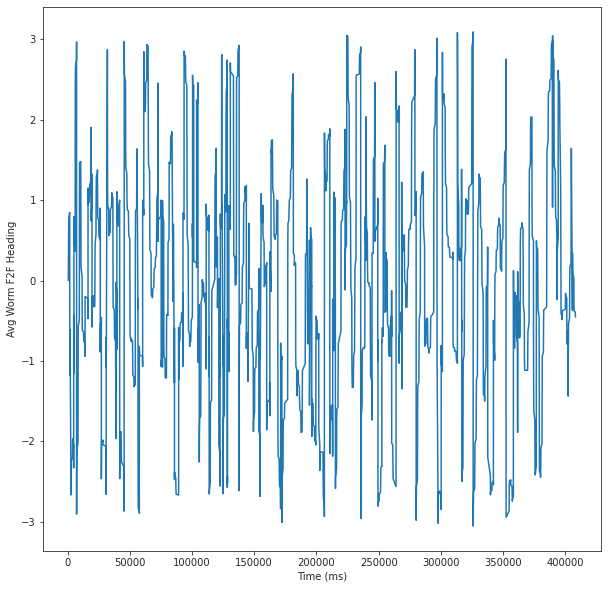

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, Avg_f2f_heading)
plt.xlabel('Time (ms)')
plt.ylabel('Avg Worm F2F Heading')
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

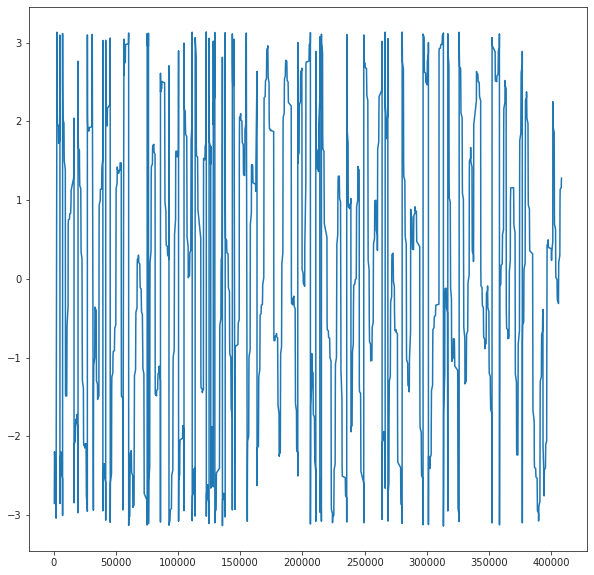

In [ ]:
AFD_f2f_line_x = []
AFD_f2f_line_y = []
for i in range(len(Head_x)):
    AFD_f2f_line_x.append(AFD_x[i]-AFD_x[i-1])
    AFD_f2f_line_y.append(-(AFD_y[i]-AFD_y[i-1]))
AFD_f2f_heading = np.arctan2(AFD_f2f_line_y,AFD_f2f_line_x)

plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, AFD_f2f_heading)
#plt.xlabel('Time (ms)')
#plt.ylabel('Soma Ratio')
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

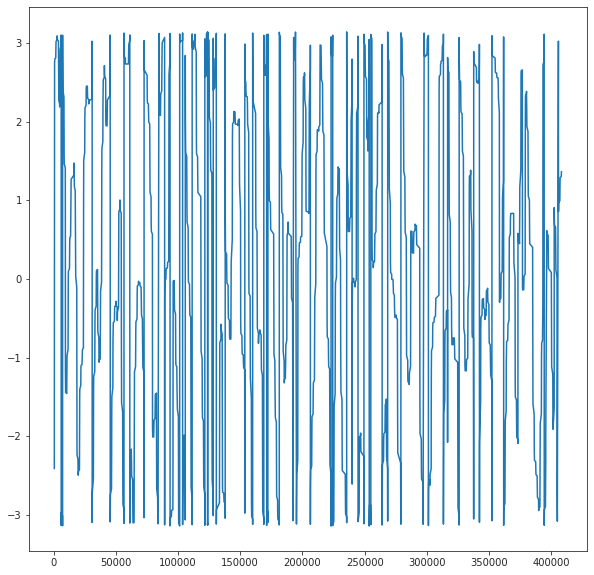

In [ ]:
Neck_f2f_line_x = []
Neck_f2f_line_y = []
for i in range(len(Head_x)):
    Neck_f2f_line_x.append(Neck_x[i]-Neck_x[i-1])
    Neck_f2f_line_y.append(-(Neck_y[i]-Neck_y[i-1]))
Neck_f2f_heading2 = np.arctan2(Neck_f2f_line_y,Neck_f2f_line_x)

plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, Neck_f2f_heading2)
#plt.xlabel('Time (ms)')
#plt.ylabel('Soma Ratio')
plt.show()
plt.close()

In [ ]:
""" 
yNeck_f2fsmooth_line_x = []
Neck_f2fsmooth_line_y = []
for i in range(len(Head_x)):
    Neck_f2fsmooth_line_x.append((Neck_x[i+2]+Neck_x[i+1]+Neck_x[i])-(Neck_x[i-1]+Neck_x[i-2]+Neck_x[i-3]))
    Neck_f2fsmooth_line_y.append((Neck_x[i+2]+Neck_y[i+1]+Neck_y[i])-(Neck_y[i-1]+Neck_y[i-2]+Neck_y[i-3]))
Neck_f2f_heading3 = np.arctan2(Neck_f2fsmooth_line_y,Neck_f2fsmooth_line_x)

plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, Neck_f2f_heading3)
#plt.xlabel('Time (ms)')
#plt.ylabel('Soma Ratio')
plt.show()
plt.close() """

" \nyNeck_f2fsmooth_line_x = []\nNeck_f2fsmooth_line_y = []\nfor i in range(len(Head_x)):\n    Neck_f2fsmooth_line_x.append((Neck_x[i+2]+Neck_x[i+1]+Neck_x[i])-(Neck_x[i-1]+Neck_x[i-2]+Neck_x[i-3]))\n    Neck_f2fsmooth_line_y.append((Neck_x[i+2]+Neck_y[i+1]+Neck_y[i])-(Neck_y[i-1]+Neck_y[i-2]+Neck_y[i-3]))\nNeck_f2f_heading3 = np.arctan2(Neck_f2fsmooth_line_y,Neck_f2fsmooth_line_x)\n\nplt.clf()\nplt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)\nplt.plot(DLC_time, Neck_f2f_heading3)\n#plt.xlabel('Time (ms)')\n#plt.ylabel('Soma Ratio')\nplt.show()\nplt.close() "

In [ ]:
directional_velocity = [Avg_velo[0]]
AFD_Neck_heading_deriv = np.append([0],np.diff(abs(AFD_Neck_heading)))
#DLC_Time_deriv = np.append([0],np.diff(DLC_Time_deriv))
#DLC_Time_deriv  = np.array([0].extend(np.diff(DLC_time))
DLC_Time_deriv = np.append([0],(np.diff(DLC_time)))
print(DLC_Time_deriv)

radial_velocity = AFD_Neck_heading_deriv/DLC_Time_deriv
ranges_omega = []
checker = 0
for i in range(len(radial_velocity)):
    if radial_velocity[i] < -0.0124 and checker == 0 and any([radial_velocity[j] < -0.0124 for j in range(i+1, i+30)]):
        start = i
        checker = 1
    elif radial_velocity[i] < -0.0124 and checker == 1 and not any([radial_velocity[j] < -0.0124 for j in range(i+1, i+30)]):
        ranges_omega.append((start,i))
        checker = 0
    elif radial_velocity[i] < -0.0124 and checker == 0:
        ranges_omega.append((i, i+1))
#AFD_Neck_heading_deriv = [0]
#AFD_Neck_heading_deriv = AFD_Neck_heading_deriv.extend(np.diff(AFD_Neck_heading))
#AFD_Neck_heading_deriv = np.append(AFD_Neck_heading_deriv,(np.diff(AFD_Neck_heading)))
#DLC_Time_deriv = [0]
#DLC_Time_deriv = DLC_Time_deriv.extend(np.diff(DLC_time))
#DLC_Time_deriv = np.append(DLC_Time_deriv,(np.diff(DLC_time)))
  
for i in range(1,len(AFD_x)):
    previous_dist = np.sqrt((AFD_x[i-1]-Neck_x[i-1])**2+(AFD_y[i-1]-Neck_y[i-1])**2)
    new_dist = np.sqrt((AFD_x[i-1]-Neck_x[i])**2+(AFD_y[i-1]-Neck_y[i])**2)
    if new_dist < previous_dist:
        directional_velocity.append(Avg_velo[i])
    elif new_dist >= previous_dist:
        directional_velocity.append(-Avg_velo[i])




[  0 162   6 ...  27  44  27]


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in true_divide
  


In [ ]:
#for i in range(len(directional_velocity)):
#    if directional_velocity[i] < -0.5:
#        print(i)


ranges_reversal = []
checker = 0
for i in range(len(directional_velocity)):
    if directional_velocity[i] < -0.5 and abs(radial_velocity[i]) < 0.005 and checker == 0 and any([directional_velocity[j] < -0.5 and abs(radial_velocity[j]) < 0.005 for j in range(i+1, i+30)]):
        start = i
        checker = 1
    elif directional_velocity[i] < -0.5 and abs(radial_velocity[i]) < 0.005 and checker == 1 and not any([directional_velocity[j] < -0.5 and abs(radial_velocity[j]) < 0.005 for j in range(i+1, i+30)]):
        ranges_reversal.append((start,i))
        checker = 0

In [ ]:
DLC_time[4836:4838]

[395411, 395416]

<Figure size 432x288 with 0 Axes>

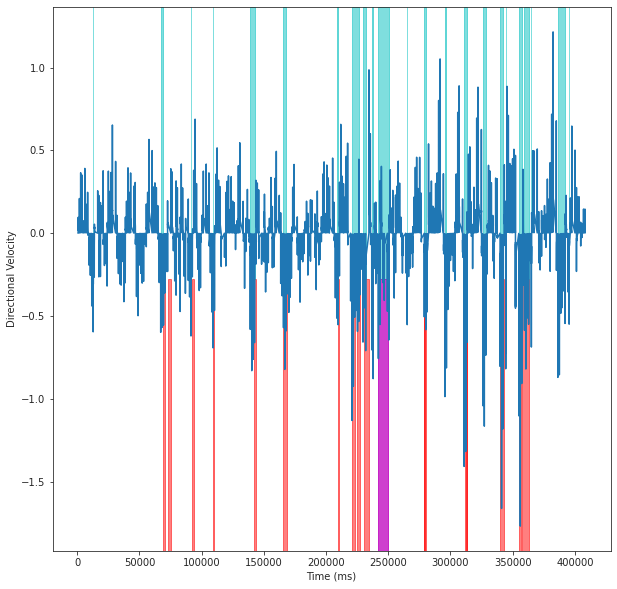

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, directional_velocity)

plt.xlabel('Time (ms)')
plt.ylabel('Directional Velocity')
plt.axvspan(69271, 70309, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(72555, 75147, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(92494, 93553, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(109240, 110268, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(142468, 143618, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(165757, 168948, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(209661, 210776, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(220851, 222991, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(225248, 227425, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(230622, 234453, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(278944, 280118, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(312284, 313323, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(278933, 279200, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(311417, 313314, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(339885, 343274, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(354920, 356393, 0, 0.5, color='r',alpha=0.5)
plt.axvspan(357542, 362824, 0, 0.5, color='r',alpha=0.5)

plt.axvspan(12782, 12798, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(67072, 69293, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(91431, 91442, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(109259, 109265, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(139081, 142506, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(165786, 167863, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(208593, 209695, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(220851, 226330, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(229682, 231844, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(236727, 237894, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(242062, 250420, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(265248, 265254, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(278985, 280158, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(295551, 296811, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(310971, 313353, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(325995, 328422, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(339897, 342148, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(344417, 344546, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(354938, 357322, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(359505, 362828, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(365028, 365039, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(386326, 392118, 0.5, 1, color='c',alpha=0.5)
plt.axvspan(395411, 395416, 0.5, 1, color='c',alpha=0.5)

plt.axvspan(242068, 249530, 0, 0.5, color='m',alpha=0.5)
plt.axvspan(242055, 249503, 0, 0.5, color='m',alpha=0.5)
plt.show()
plt.close()


<Figure size 432x288 with 0 Axes>

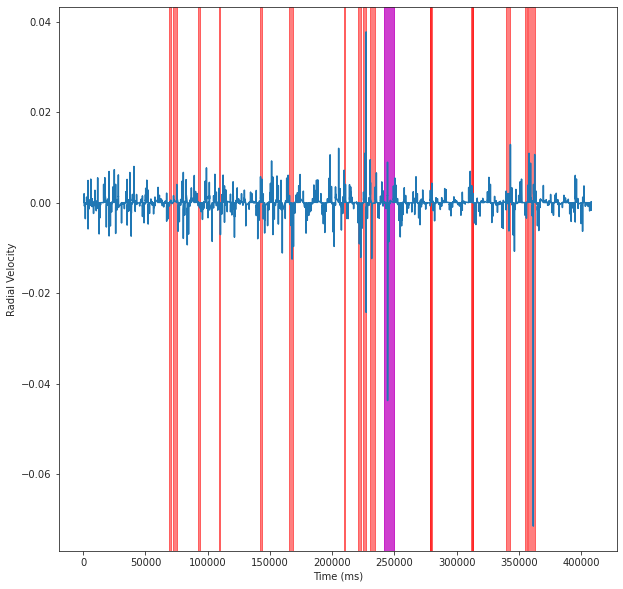

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, radial_velocity)
plt.xlabel('Time (ms)')
plt.ylabel('Radial Velocity')
plt.axvspan(69271, 70309, color='r',alpha=0.5)
plt.axvspan(72555, 75147, color='r',alpha=0.5)
plt.axvspan(92494, 93553, color='r',alpha=0.5)
plt.axvspan(109240, 110268, color='r',alpha=0.5)
plt.axvspan(142468, 143618, color='r',alpha=0.5)
plt.axvspan(165757, 168948, color='r',alpha=0.5)
plt.axvspan(209661, 210776, color='r',alpha=0.5)
plt.axvspan(220851, 222991, color='r',alpha=0.5)
plt.axvspan(225248, 227425, color='r',alpha=0.5)
plt.axvspan(230622, 234453, color='r',alpha=0.5)
plt.axvspan(242068, 249530, color='m',alpha=0.5)
plt.axvspan(278944, 280118, color='r',alpha=0.5)
plt.axvspan(312284, 313323, color='r',alpha=0.5)
plt.axvspan(242055, 249503, color='m',alpha=0.5)
plt.axvspan(278933, 279200, color='r',alpha=0.5)
plt.axvspan(311417, 313314, color='r',alpha=0.5)
plt.axvspan(339885, 343274, color='r',alpha=0.5)
plt.axvspan(354920, 356393, color='r',alpha=0.5)
plt.axvspan(357542, 362824, color='r',alpha=0.5)
plt.show()
plt.close()

In [ ]:
DLC_time[2071:2234]

[167823,
 167832,
 167840,
 167846,
 167852,
 167858,
 167863,
 167886,
 167909,
 167952,
 167978,
 168004,
 168049,
 168076,
 168939,
 168948,
 168956,
 168963,
 168970,
 168975,
 168981,
 168986,
 169009,
 169052,
 169077,
 169101,
 169144,
 169168,
 169212,
 170034,
 170043,
 170052,
 170059,
 170066,
 170071,
 170077,
 170082,
 170107,
 170152,
 170178,
 170203,
 170245,
 170270,
 170315,
 171063,
 171072,
 171081,
 171088,
 171094,
 171100,
 171143,
 171170,
 171197,
 171242,
 171269,
 171295,
 171322,
 171365,
 171391,
 172120,
 172130,
 172139,
 172146,
 172153,
 172158,
 172199,
 172223,
 172269,
 172295,
 172321,
 172348,
 172375,
 172419,
 172446,
 173149,
 173158,
 173167,
 173174,
 173181,
 173186,
 173211,
 173256,
 173283,
 173310,
 173354,
 173381,
 173408,
 173435,
 173480,
 174252,
 174262,
 174271,
 174279,
 174285,
 174291,
 174296,
 174307,
 174313,
 174354,
 174379,
 174406,
 174451,
 174477,
 174504,
 176868,
 176878,
 176887,
 176896,
 176902,
 176908,
 176913,
 

<Figure size 432x288 with 0 Axes>

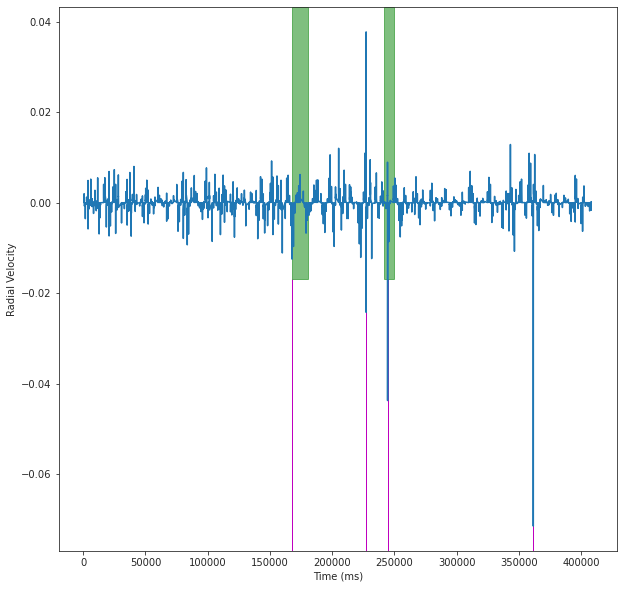

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, radial_velocity)
plt.xlabel('Time (ms)')
plt.ylabel('Radial Velocity')
for i in ranges_omega:
    plt.axvspan(DLC_time[i[0]], DLC_time[i[1]], 0, 0.5, color='m',alpha=1)
plt.axvspan(167823, 180370, 0.5, 1, color='g',alpha=0.5)
plt.axvspan(242068, 249503, 0.5, 1, color='g',alpha=0.5)

plt.show()
plt.close()


In [ ]:
print(ranges_omega)
radial_velocity[2824]
radial_velocity[3041]

[(2077, 2078), (2824, 2825), (3041, 3043), (4427, 4434)]


-0.04376083856701829

<Figure size 432x288 with 0 Axes>

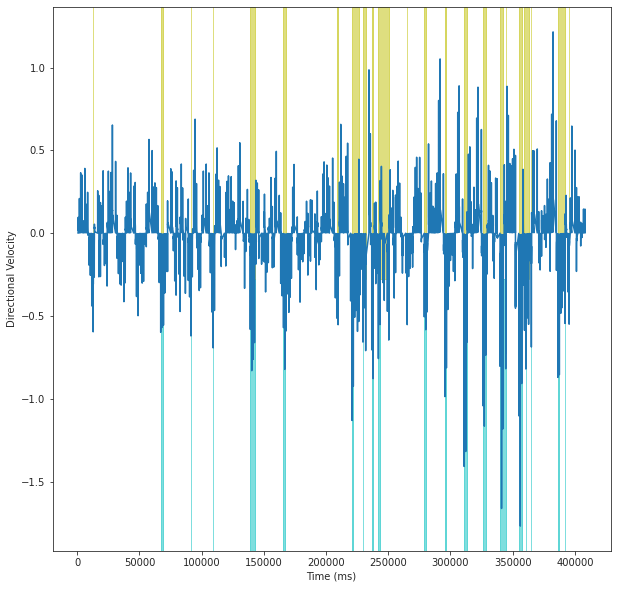

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, directional_velocity)
plt.xlabel('Time (ms)')
plt.ylabel('Directional Velocity')
for i in ranges_reversal:
    plt.axvspan(DLC_time[i[0]], DLC_time[i[1]], 0, 0.5, color='c',alpha=0.5)
plt.axvspan(12782, 12798, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(67072, 69293, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(91431, 91442, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(109259, 109265, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(139081, 142506, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(165786, 167863, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(208593, 209695, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(220851, 226330, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(229682, 231844, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(236727, 237894, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(242062, 250420, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(265248, 265254, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(278985, 280158, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(295551, 296811, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(310971, 313353, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(325995, 328422, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(339897, 342148, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(344417, 344546, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(354938, 357322, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(359505, 362828, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(365028, 365039, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(386326, 392118, 0.5, 1, color='y',alpha=0.5)
plt.axvspan(395411, 395416, 0.5, 1, color='y',alpha=0.5)
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

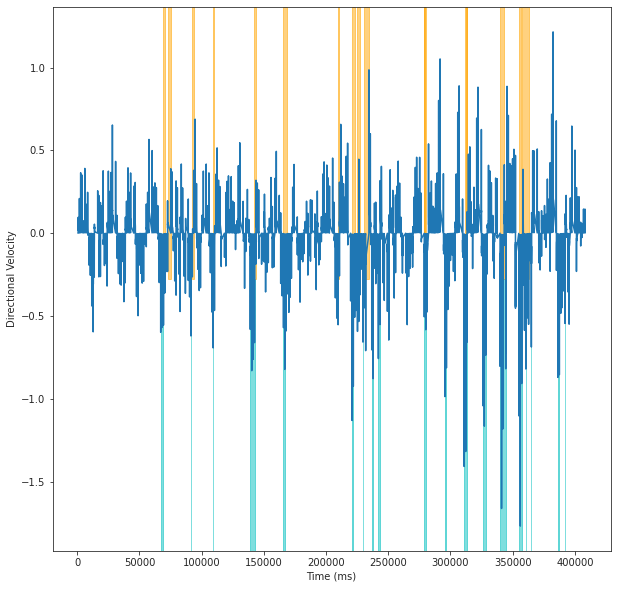

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, directional_velocity)
plt.xlabel('Time (ms)')
plt.ylabel('Directional Velocity')
for i in ranges_reversal:
    plt.axvspan(DLC_time[i[0]], DLC_time[i[1]], 0, 0.5, color='c',alpha=0.5)
plt.axvspan(69271, 70309, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(72555, 75147, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(92494, 93553, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(109240, 110268, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(142468, 143618, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(165757, 168948, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(209661, 210776, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(220851, 222991, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(225248, 227425, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(230622, 234453, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(278944, 280118, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(312284, 313323, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(278933, 279200, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(311417, 313314, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(339885, 343274, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(354920, 356393, 0.5, 1, color='orange',alpha=0.5)
plt.axvspan(357542, 362824, 0.5, 1, color='orange',alpha=0.5)
plt.show()
plt.close()

In [ ]:
#def heading(x, y): 
#    if x > 0 and y > 0: 
#        return math.atan(y / x)
#    if x > 0:
#        return math.pi + math.atan(y / x)
#    return 2 * math.pi + math.atan(y / x)

#HeadminusNeck_x = [h - n for h, n in zip(Head_x, Neck_x)]
#HeadminusNeck_y = [h - n for h, n in zip(Head_y, Neck_y)]
#HeadingHeadminusNeck = [heading(x, y) for x, y in zip(HeadminusNeck_x, HeadminusNeck_y)]

In [ ]:
ranges_runcalls = []
checker = 0

for i in range(len(directional_velocity)):
    if directional_velocity[i] > 0.2 and abs(radial_velocity[i]) < 0.1 and checker == 0 and any([directional_velocity[j] > 0.2 and abs(radial_velocity[j]) < 0.1 for j in range(i+1, i+30)]):
        start = i
        checker = 1
    elif directional_velocity[i] > 0.2 and abs(radial_velocity[i]) < 0.1 and checker == 1 and not any([directional_velocity[j] > 0.2 and abs(radial_velocity[j]) < 0.1 for j in range(i+1, i+30)]):
        ranges_runcalls.append((start,i))
        checker = 0

<Figure size 432x288 with 0 Axes>

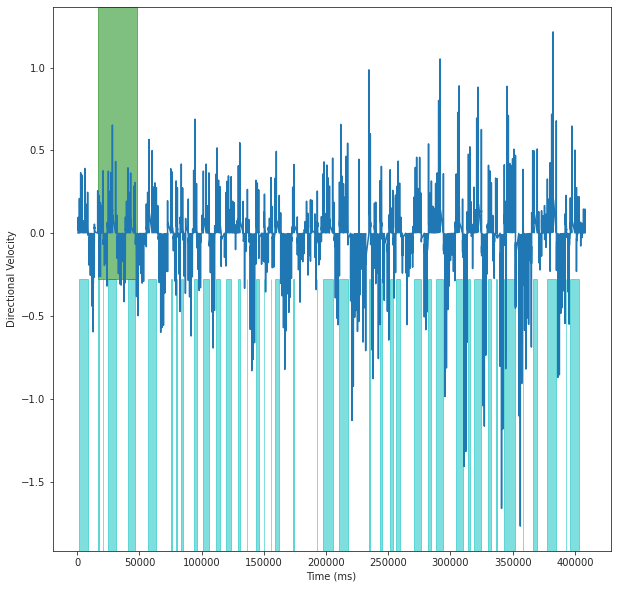

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(DLC_time, directional_velocity)
plt.xlabel('Time (ms)')
plt.ylabel('Directional Velocity')
for i in ranges_runcalls:
    plt.axvspan(DLC_time[i[0]], DLC_time[i[1]], 0, 0.5, color='c',alpha=0.5)
plt.axvspan(16410, 47773, 0.5, 1, color='g',alpha=0.5)
plt.show()
plt.close()

In [ ]:
for i in ranges_runcalls:
    print([i])
    print(np.mean(AFD_Neck_heading[i[0]:i[1]]))



[(19, 111)]
-0.3278058615485958
[(202, 211)]
2.3937895804523386
[(257, 263)]
-2.0179111472242504
[(316, 383)]
-0.6217911064498799
[(513, 577)]
0.9282946875580326
[(710, 786)]
2.7797538774671815
[(917, 937)]
1.1546432291058668
[(981, 997)]
-2.123672976430236
[(1036, 1053)]
-2.6484019378855885
[(1158, 1192)]
-2.7705488004258467
[(1261, 1310)]
-1.300164733206377
[(1382, 1432)]
0.5003764924627732
[(1475, 1536)]
0.5798448700301394
[(1609, 1627)]
0.6678315063728163
[(1683, 1687)]
-3.054507563403062
[(1774, 1807)]
-0.4180054986073308
[(1857, 1858)]
-2.212828234189043
[(1922, 1927)]
2.7579942367884263
[(1969, 2001)]
1.4812842128509187
[(2150, 2168)]
1.3829267393862819
[(2386, 2387)]
1.6483334079327203
[(2448, 2542)]
1.441145390846912
[(2615, 2707)]
2.4401980922075
[(2896, 2917)]
2.5195381405319237
[(3026, 3041)]
-2.1617255918555123
[(3106, 3140)]
1.5919482436062042
[(3170, 3217)]
0.292027675785861
[(3349, 3425)]
0.07187115518488774
[(3481, 3517)]
-0.09648618483016883
[(3559, 3622)]
0.238246602

In [ ]:
East_list = []
West_list = []
North_list = []
South_list = []


for i in ranges_runcalls:
    frameHeading = np.mean(AFD_Neck_heading[i[0]:i[1]])
    if -np.pi/4 < frameHeading <= -0.75*np.pi:
        South_list.append(i)
    elif np.pi/4 < frameHeading <= 0.75*np.pi:
        North_list.append(i)
    elif -0.75*np.pi > frameHeading <= 0.75*np.pi:
        West_list.append(i)
    elif -0.25*np.pi < frameHeading <= 0.25*np.pi:
        East_list.append(i)

        


<Figure size 432x288 with 0 Axes>

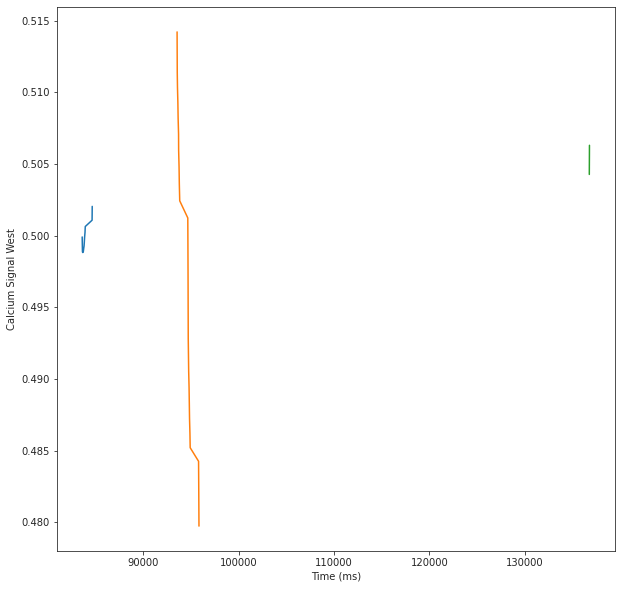

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
for i in West_list:
     plt.plot(DLC_time[i[0]:i[1]],Soma_Ratio_smoothed[i[0]:i[1]]), plt.xlabel('Time (ms)')
     plt.ylabel('Calcium Signal West')


plt.show()
plt.close()

In [ ]:
print(West_list)

[(1036, 1053), (1158, 1192), (1683, 1687)]


<Figure size 432x288 with 0 Axes>

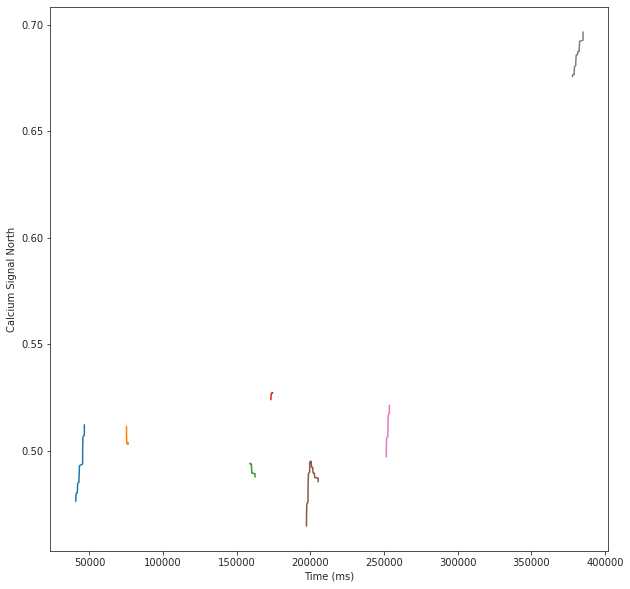

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
for i in North_list:
     plt.plot(DLC_time[i[0]:i[1]],Soma_Ratio_smoothed[i[0]:i[1]]), plt.xlabel('Time (ms)')
     plt.ylabel('Calcium Signal North')


plt.show()
plt.close()

ValueError: ignored

<Figure size 432x288 with 0 Axes>

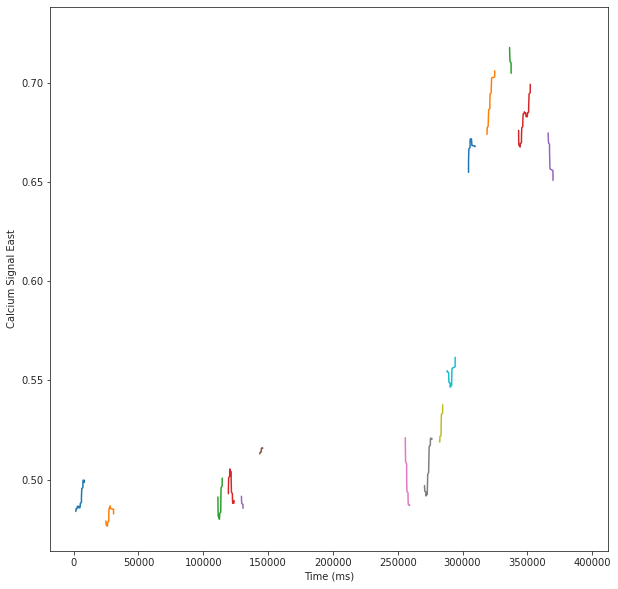

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
for i in East_list:
     plt.plot(DLC_time[i[0]:i[1]],Soma_Ratio_smoothed[i[0]:i[1]]), plt.xlabel('Time (ms)')
     plt.ylabel('Calcium Signal East')


plt.show()
plt.close()

In [ ]:
plt.clf()
plt.figure(figsize=(10,10))#,dpi=300)#plt.ylim(0,1)
for i in South_list:
     plt.plot(DLC_time[i[0]:i[1]],Soma_Ratio_smoothed[i[0]:i[1]]), plt.xlabel('Time (ms)')
     plt.ylabel('Calcium Signal South')


plt.show()
plt.close()

In [ ]:
manual_spans_omega = [(2071,2234),(3002,3090)]
manual_spans_reversal = [(856,871),(901,917),(1144,1159),(1352,1368),(1756,1772),(2042,2087),(2596,2618),(2731,2763),(2792,2827),(2865,2897),(3436,3452),(3826,3842),(4160,4202),(4337,4366),(4381,4449)]

In [ ]:
#Percent Omega ,Radial

total_count = 0
total_frames = 0
overlap_count = 0
overlap_frames = 0
falsenegative_count = 0

for i in manual_spans_omega:
    total_count += 1
    total_frames += (i[1]-i[0])
    check = 0
    for j in ranges_omega:
        if (j[0] > i[0] and j[0] < i[1]):
            if check == 0:
                overlap_count += 1
                check = 1
            overlap_frames += (min([i[1],j[1]]) - j[0])
        elif (i[0] > j[0] and i[0] < j[1]):
            if check == 0:
                overlap_count += 1
                check = 1
            overlap_frames += (min([i[1],j[1]]) - i[0])
    if check == 0:
      falsenegative_count += 1
  
percent_called = (float(overlap_count)/total_count)*100
percent_overlap = (float(overlap_frames)/total_frames)*100
percent_falsenegative = (float(falsenegative_count)/total_count)*100
print(percent_called, percent_overlap)
print(falsenegative_count)
print(percent_falsenegative)

In [ ]:
#Percent False Positive ,Radial
#NEW, radial percent false positive shows the percent omega turns that the computer is marking wrong
total_count = 0
total_frames = 0
overlap_count = 0
overlap_frames = 0

for i in ranges_omega:
    total_count += 1
    total_frames += (i[1]-i[0])
    check = 0
    for j in manual_spans_omega:
        if (j[0] > i[0] and j[0] < i[1]):
            if check == 0:
                overlap_count += 1
                check = 1
            overlap_frames += (min([i[1],j[1]]) - j[0])
        elif (i[0] > j[0] and i[0] < j[1]):
            if check == 0:
                overlap_count += 1
                check = 1
            overlap_frames += (min([i[1],j[1]]) - i[0])   
percent_called = (float(overlap_count)/total_count)*100
percent_falsepositive = (float(overlap_frames)/total_frames)*100
print(percent_called, percent_falsepositive)


In [ ]:
#Percent Reversal ,Directional


total_count = 0
total_frames = 0
overlap_count = 0
overlap_frames = 0
falsenegative_count = 0

for i in manual_spans_reversal:
    total_count += 1
    total_frames += (i[1]-i[0])
    check = 0
    for j in ranges_reversal:
        if (j[0] > i[0] and j[0] < i[1]):
            if check == 0:
                overlap_count += 1
                check = 1
            overlap_frames += (min([i[1],j[1]]) - j[0])
        elif (i[0] > j[0] and i[0] < j[1]):
            if check == 0:
                overlap_count += 1
                check = 1
            overlap_frames += (min([i[1],j[1]]) - i[0])
    if check == 0:
      falsenegative_count += 1

percent_called = (float(overlap_count)/total_count)*100
percent_overlap = (float(overlap_frames)/total_frames)*100
percent_falsenegative = (float(falsenegative_count)/total_count)*100
print(percent_called, percent_overlap)
print(falsenegative_count)
print(percent_falsenegative)

In [ ]:
#Percent False Positive, Directional
#NEW, radial percent false positive shows the percent reversal turns that the computer is marking wrong

total_count = 0
total_frames = 0
overlap_count = 0
overlap_frames = 0

for i in ranges_reversal:
    total_count += 1
    total_frames += (i[1]-i[0])
    check = 0
    for j in manual_spans_reversal:
        if (j[0] > i[0] and j[0] < i[1]):
            if check == 0:
                overlap_count += 1
                check = 1
            overlap_frames += (min([i[1],j[1]]) - j[0])
        elif (i[0] > j[0] and i[0] < j[1]):
            if check == 0:
                overlap_count += 1
                check = 1
            overlap_frames += (min([i[1],j[1]]) - i[0])   
percent_called = (float(overlap_count)/total_count)*100
percent_falsepositive = (float(overlap_frames)/total_frames)*100
print(percent_called, percent_falsepositive)

In [ ]:
plt.clf()
plt.figure(figsize=(12,10))#,dpi=300)#plt.ylim(0,1)
plt.plot(smoothed_TxTip,NeuronYPos,'k')
plt.scatter(smoothed_TxTip,NeuronYPos, c=Soma_Ratio_smoothed, cmap='bwr', s=500)
plt.xlabel('Temperature', fontsize=15)
plt.ylabel('neuronypos', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=15)
cbar.set_label('AFD Soma GCaMP/RFP Ratio', rotation=270,fontsize=15,labelpad=20)
plt.show()
plt.close

In [ ]:

%matplotlib notebook
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def animate(i):

    plt.scatter(smoothed_TxTip[:i],NeuronYPos[:i],c=Soma_Ratio_smoothed[:i], cmap='bwr', s=500)
    return plot
Writer = animation.writers['html']
writer = Writer(fps=3, metadata=dict(artist='Me'), bitrate=1800)

fig = plt.figure()
ani = matplotlib.animation.FuncAnimation(fig, animate, frames=len(smoothed_TxTip), repeat=True)

plt.xlim(min(smoothed_TxTip),max(smoothed_TxTip))
plt.ylim(min(NeuronYPos),max(NeuronYPos))


plt.show()

ani
#ani.save('test.html', writer=writer)



In [ ]:
fig = plt.figure(figsize = (1.5,1), dpi=10)

matplotlib.rcParams['animation.embed_limit'] = 2**128



def frame(i):
    ax.clear()  

    plt.title('PLACEHOLDER')
    ax.set_xlabel('X AXIS')
    ax.set_xlim(min(smoothed_TxTip),max(smoothed_TxTip))
    ax.set_ylabel('Y AXIS')
    ax.set_ylim(min(NeuronYPos),max(NeuronYPos))
    plot = plt.scatter(smoothed_TxTip[:i],NeuronYPos[:i],c=Soma_Ratio_smoothed[:i], cmap='bwr', s=50)
    return plot


ani = matplotlib.animation.FuncAnimation(fig, frame, frames=250, blit=False, repeat=True)




ani


#ani.save('test.html', writer=writer)
#len(smoothed_TxTip)